# Análisis Exploratorio de Datos (EDA) — Mercado inmobiliario de CABA

**Fuente:** MercadoLibre Inmuebles, scraping del 14 al 17/08/2026, enriquecido con datos externos (subte, hospitales, delitos, colectivos).
**Unidad de análisis:** un aviso publicado (una fila = una propiedad).

Estructura del notebook:
1. Carga de datos
2. Descripción de las variables (diccionario de datos)
3. Análisis univariado de variables cualitativas
4. Análisis univariado de variables cuantitativas
5. Análisis multivariado

## 1. Carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Estilo de los gráficos: un único color para las barras y gris para "Sin dato"
COLOR = '#2a78d6'
COLOR_NA = '#b5b3ad'
sns.set_theme(style='whitegrid', rc={'grid.color': '#e6e5e1', 'axes.edgecolor': '#d0cfc9'})

In [3]:
from pathlib import Path
import os

ARCHIVO_DATOS = Path('data') / 'processed' / 'dataframefinal.csv'

def buscar_datos(relativa=ARCHIVO_DATOS):
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / relativa).is_file():
            return carpeta / relativa
    raise FileNotFoundError(
        f'No se encontró {relativa} subiendo desde {actual}. '
    )

RUTA = Path(os.getenv('RUTA_DATOS') or buscar_datos())
print('Leyendo:', RUTA)

# low_memory=False evita el DtypeWarning de 'Tipo_Alquiler' (columna casi vacía en las ventas)
RUTA = Path(os.getenv('RUTA_DATOS') or buscar_datos())
print('Leyendo:', RUTA)

# low_memory=False evita el DtypeWarning de 'Tipo_Alquiler' (columna casi vacía en las ventas)
df = pd.read_csv(RUTA, low_memory=False)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Leyendo: /Users/valentinzuppa/Desktop/TP-Analisis-Descriptivo-Inmobiliario-CABA/data/processed/dataframefinal.csv
Leyendo: /Users/valentinzuppa/Desktop/TP-Analisis-Descriptivo-Inmobiliario-CABA/data/processed/dataframefinal.csv
Filas: 55,582 | Columnas: 88


,Fuente,Item_ID,Tipo_Operacion,Tipo_Alquiler,Tipo_Propiedad,Subtipo_Propiedad,Titulo,Tipo_Vendedor,Precio_Raw,Precio,Moneda,Expensas_Raw,Expensas,Moneda_Expensas,Direccion_Publicada,Calle,Altura,Barrio_Publicado,Latitud,Longitud,Piso,Ambientes,Dormitorios,Baños,Cocheras,Bauleras,Superficie_Total_m2,Superficie_Cubierta_m2,Superficie_No_Cubierta_m2,Superficie_Balcon_m2,Antiguedad,Cantidad_Pisos_Edificio,Departamentos_Por_Piso,Disposicion,Orientacion,Estado_Inmueble,Admite_Mascotas,Apto_Credito,Apto_Profesional,Amoblado,Ascensor,Balcon,Terraza,Patio,Pileta,Parrilla,SUM,Gimnasio,Laundry,Seguridad,Aire_Acondicionado,Calefaccion,Lavadero,Dormitorio_Suite,Link,Fecha_Scraping,Flag_Precio_Anomalo,Flag_Operacion_Anomala,Flag_Tipo_Propiedad_Anomalo,Flag_Superficie_Anomala,Flag_Ambientes_Anomalo,Flag_Coordenadas_Anomalas,Flag_Expensas_Anomalas,Flag_Amenities_Anomalos,Flag_Faltantes_Criticos,Flag_Anomalia_General,Motivo_Anomalia,Barrio_Normalizado,Precio_USD,Expensas_USD,Antiguedad_limpia,Precio_m2_USD,p1_m2,p99_m2,Ambientes_Agrupado,Tasa_Confort_Amenities,Antiguedad_Rango,Confort_Rango,Precio_Predicho_USD,Indice_Subvaluacion,Rentabilidad_Neta_Zona,Distancia_Subte_m,Distancia_Hospital_m,Cantidad_Delitos_1000m,Cantidad_Colectivos_500m,Distancia_Espacio_Verde_m,Cantidad_Espacios_Verdes_1000m,Superficie_Verde_1000m_m2
0,Mercado Libre,MLA3224379444,Venta,NaN,Departamento,NaN,Se Vende Un Departamento De 3 Ambientes Al Frente - Balvanera,Inmobiliaria,US$ 100.000,"100,000.00",USD,100.000 ARS,"100,000.00",ARS,Tte. Gral. Juan Domingo Peron 1700,Tte. Gral. Juan Domingo Peron,"1,700.00",Balvanera,-34.61,-58.39,NaN,3.00,2.00,1.00,0.00,NaN,56.00,56.00,0.00,NaN,39.00,9.00,NaN,NaN,NaN,Desconocido,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,https://departamento.mercadolibre.com.ar/MLA-3224379444-se-vende-un-departamento-de-3-ambientes-al-frente-balvanera-_JM,2026-08-14T11:22:54-03:00,0,0,0,0,0,0,0,0,0,0,Sin anomalías detectadas,Balvanera,"100,000.00",65.70,39.00,"1,785.71",550.42,"6,756.76",3,0.00,30-50,Bajo,"89,241.24",0.12,0.05,304.08,"1,819.18","20,036.00",75.00,312.58,8.00,"54,450.76"
1,Mercado Libre,MLA3558686250,Venta,NaN,Departamento,NaN,Venta Departamento - 4 Ambientes - Palermo,Inmobiliaria,US$ 179.000,"179,000.00",USD,NaN,NaN,NaN,Arenales 3600,Arenales,"3,600.00",Palermo,-34.59,-58.41,NaN,4.00,3.00,1.00,0.00,1.00,77.00,77.00,0.00,NaN,69.00,NaN,NaN,NaN,NaN,Desconocido,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,https://departamento.mercadolibre.com.ar/MLA-3558686250-venta-departamento-4-ambientes-palermo-_JM,2026-08-14T11:22:57-03:00,0,0,0,0,0,0,0,0,0,0,Sin anomalías detectadas,Palermo,"179,000.00",NaN,69.00,"2,324.68",550.42,"6,756.76",4+,0.13,50+,Bajo,"180,270.59",-0.01,0.06,266.35,774.57,"14,637.00",59.00,315.19,9.00,"142,840.65"
2,Mercado Libre,MLA1945483967,Venta,NaN,Departamento,NaN,Venta Departamento 3 Amb Desarrollo Villa Urquiza,Inmobiliaria,US$ 315.000,"315,000.00",USD,0 ARS,0.00,ARS,Bauness 2700,Bauness,"2,700.00",Villa Urquiza,-34.57,-58.49,12.00,3.00,2.00,1.00,1.00,0.00,120.00,82.00,38.00,38.00,0.00,12.00,99.00,Frente,Norte,En pozo,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,https://departamento.mercadolibre.com.ar/MLA-1945483967-venta-departamento-3-amb-desarrollo-villa-urquiza-_JM,2026-08-14T11:23:00-03:00,0,0,0,0,0,0,1,1,0,1,"Expensas cero sospechosas | Conflicto ML/texto en amenities: Terraza, Aire_Acondicionado, Calefaccion",Villa Urquiza,"315,000.00",0.00,0.00,"2,625.00",550.42,"6,756.76",3,0.13,0-10,Bajo,"305,668.45",0.03,0.04,339.08,"1,911.98","5,742.00",39.00,62.16,4.00,"7,245.56"
3,Mercado Libre,MLA1945603777,Venta,NaN,Departamento,Penthhouse,Penthouse Dúplex Con Jardín Y Vista Al Río - Nuñez,Inmobiliaria,US$ 870.000,"870,000.00",USD,1.300.000 ARS,"1,300,000.00",ARS,Jaramillo 2000,Jaramillo,"2,000.00",Núñez,-34.55,-58.46,22.00,5.00,4.00,3.00,3.00,0.00,241.00,183.00,58.00,NaN,29.00,22.00,99.00,Frente,Este,Desconocido,0,0,0,0,0,0,1,0,1,0,1,1,0,1,0,0,1,1,https://departamento.mercadolibre.com.ar/MLA-1945603777-penthouse-duplex-con-jardin-y-vista-al-ri

In [4]:
# Chequeos básicos de integridad
print('Avisos duplicados (Item_ID):', df['Item_ID'].duplicated().sum())
print('Filas completamente duplicadas:', df.duplicated().sum())
print('Período de scraping:', df['Fecha_Scraping'].min()[:10], 'a', df['Fecha_Scraping'].max()[:10])

Avisos duplicados (Item_ID): 0
Filas completamente duplicadas: 0
Período de scraping: 2026-08-14 a 2026-08-17


## 2. Descripción de las variables

El dataset tiene 55.582 avisos y 88 variables, agrupadas por temática.

**Identificación del aviso**
* Fuente: página de donde fue sacado el dato (en todos los casos, MercadoLibre).
* Item_ID: código único con el que MercadoLibre identifica al aviso (ej. MLA3224379444).
* Titulo: título del aviso tal como lo escribió el anunciante.
* Link: dirección web (URL) del aviso.
* Fecha_Scraping: fecha y hora en que se descargó el aviso (entre el 14 y el 17/08/2026).

**Operación y tipo de inmueble**
* Tipo_Operacion: si la propiedad se ofrece en venta o en alquiler.
* Tipo_Alquiler: solo para alquileres, indica si es tradicional o temporario; en las ventas está vacío.
* Tipo_Propiedad: tipo de inmueble: departamento, PH o casa.
* Subtipo_Propiedad: detalle del tipo de inmueble cuando el aviso lo informa (monoambiente, dúplex, semipiso, loft, tríplex, piso, penthouse, chalet).
* Tipo_Vendedor: quién publica el aviso: una inmobiliaria o un particular.
* Estado_Inmueble: estado de la propiedad: a estrenar, en pozo, reciclado, a refaccionar o desconocido.

**Precio y costos**
* Precio_Raw: precio tal como aparece escrito en el aviso (ej. "US$ 100.000").
* Precio: valor numérico del precio, en la moneda en que fue publicado.
* Moneda: moneda del precio (dólares o pesos).
* Expensas_Raw: expensas tal como aparecen escritas en el aviso.
* Expensas: valor numérico de las expensas mensuales, en su moneda original.
* Moneda_Expensas: moneda de las expensas (pesos o dólares).
* Precio_USD: precio expresado en dólares; los precios en pesos se convirtieron a un tipo de cambio de $1.522 por dólar.
* Expensas_USD: expensas mensuales expresadas en dólares, con el mismo tipo de cambio.
* Precio_m2_USD: precio por metro cuadrado en dólares (precio en dólares dividido la superficie total).

**Ubicación**
* Direccion_Publicada: dirección tal como figura en el aviso.
* Calle: nombre de la calle, separado de la dirección.
* Altura: numeración de la calle.
* Barrio_Publicado: barrio tal como lo escribió el anunciante, sin corregir.
* Barrio_Normalizado: barrio corregido y unificado según los 48 barrios oficiales de CABA.
* Latitud: coordenada norte-sur de la propiedad.
* Longitud: coordenada este-oeste de la propiedad.

**Características físicas**
* Piso: piso del edificio en el que está la unidad.
* Ambientes: cantidad de ambientes.
* Dormitorios: cantidad de dormitorios.
* Baños: cantidad de baños.
* Cocheras: cantidad de cocheras.
* Bauleras: cantidad de bauleras.
* Superficie_Total_m2: superficie total en m² (cubierta más descubierta).
* Superficie_Cubierta_m2: superficie techada en m².
* Superficie_No_Cubierta_m2: superficie descubierta en m² (balcones, patios, terrazas).
* Superficie_Balcon_m2: superficie del balcón en m².
* Antiguedad: años de antigüedad declarados en el aviso, sin corregir (tiene valores imposibles).
* Antiguedad_limpia: antigüedad en años ya corregida (entre 0 y 150).
* Cantidad_Pisos_Edificio: cantidad de pisos que tiene el edificio.
* Departamentos_Por_Piso: cantidad de unidades por piso.
* Disposicion: ubicación de la unidad dentro del edificio: al frente, contrafrente, lateral o interna.
* Orientacion: punto cardinal hacia el que da la propiedad: norte, sur, este u oeste.

**Condiciones comerciales** (1 = sí, 0 = no)
* Admite_Mascotas: si se permiten mascotas.
* Apto_Credito: si la propiedad se puede comprar con crédito hipotecario.
* Apto_Profesional: si se puede usar como consultorio u oficina.

**Amenities** (1 = tiene, 0 = no tiene o no lo informa)
* Amoblado: si se entrega con muebles.
* Ascensor: si el edificio tiene ascensor.
* Balcon: si tiene balcón.
* Terraza: si tiene terraza.
* Patio: si tiene patio.
* Pileta: si tiene pileta.
* Parrilla: si tiene parrilla.
* SUM: si el edificio tiene salón de usos múltiples.
* Gimnasio: si el edificio tiene gimnasio.
* Laundry: si el edificio tiene lavandería común.
* Seguridad: si tiene vigilancia o seguridad.
* Aire_Acondicionado: si tiene aire acondicionado.
* Calefaccion: si tiene calefacción.
* Lavadero: si tiene lavadero propio.
* Dormitorio_Suite: si tiene un dormitorio con baño propio.

**Control de calidad del dato** (1 = se detectó el problema)
* Flag_Precio_Anomalo: el precio está fuera de un rango razonable (ej. una venta de menos de USD 10.000).
* Flag_Operacion_Anomala: el título o la descripción contradicen el tipo de operación (ej. dice "alquiler" pero figura como venta).
* Flag_Tipo_Propiedad_Anomalo: el tipo de propiedad que informa MercadoLibre no coincide con el que se deduce del texto.
* Flag_Superficie_Anomala: la superficie es imposible (cero o negativa, menor a 10 m², o cubierta mayor que la total).
* Flag_Ambientes_Anomalo: los ambientes son incoherentes (cero ambientes, o más dormitorios que ambientes).
* Flag_Coordenadas_Anomalas: las coordenadas caen fuera de CABA.
* Flag_Expensas_Anomalas: las expensas figuran en cero y eso resulta sospechoso.
* Flag_Amenities_Anomalos: los amenities que marca MercadoLibre no coinciden con los que menciona el texto del aviso.
* Flag_Faltantes_Criticos: faltan datos imprescindibles para el análisis.
* Flag_Anomalia_General: vale 1 si el aviso tiene al menos una de las anomalías anteriores.
* Motivo_Anomalia: explicación en texto de las anomalías detectadas en el aviso.

**Variables calculadas**
* p1_m2: valor del precio por m² que deja por debajo al 1% más barato (se usa como límite inferior para detectar valores extremos).
* p99_m2: valor del precio por m² que deja por encima al 1% más caro (límite superior para detectar valores extremos).
* Ambientes_Agrupado: cantidad de ambientes agrupada en 1, 2, 3 y 4 o más.
* Tasa_Confort_Amenities: proporción de los 15 amenities que tiene la propiedad (0 = ninguno, 1 = todos).
* Antiguedad_Rango: antigüedad agrupada en rangos: 0-10, 10-30, 30-50 y más de 50 años.
* Confort_Rango: nivel de confort según la cantidad de amenities: bajo (3 o menos), medio (4 a 6) o alto (7 o más).
* Precio_Predicho_USD: precio de referencia que "debería" tener la propiedad según propiedades comparables.
* Indice_Subvaluacion: cuánto se aleja el precio publicado del precio de referencia, en proporción. Negativo = publicada por debajo de su valor de referencia (posible oportunidad); positivo = por encima.
* Rentabilidad_Neta_Zona: rentabilidad anual estimada de alquilar una propiedad similar (mismo barrio, tipo y ambientes).

**Entorno urbano** (datos externos cruzados por ubicación)
* Distancia_Subte_m: distancia en metros a la estación de subte más cercana.
* Distancia_Hospital_m: distancia en metros al hospital más cercano.
* Cantidad_Delitos_1000m: cantidad de delitos registrados en un radio de 1 km.
* Cantidad_Colectivos_500m: cantidad de paradas de colectivo en un radio de 500 m.
* Distancia_Espacio_Verde_m: distancia en metros al borde del espacio verde más cercano (plaza, parque, jardín botánico o reserva).
* Cantidad_Espacios_Verdes_1000m: cantidad de espacios verdes con algún punto a menos de 1 km.
* Superficie_Verde_1000m_m2: superficie verde total, en m², accesible dentro de ese radio de 1 km.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55582 entries, 0 to 55581
Data columns (total 88 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Fuente                          55582 non-null  str    
 1   Item_ID                         55582 non-null  str    
 2   Tipo_Operacion                  55582 non-null  str    
 3   Tipo_Alquiler                   4943 non-null   str    
 4   Tipo_Propiedad                  55582 non-null  str    
 5   Subtipo_Propiedad               15118 non-null  str    
 6   Titulo                          55582 non-null  str    
 7   Tipo_Vendedor                   55567 non-null  str    
 8   Precio_Raw                      55582 non-null  str    
 9   Precio                          55582 non-null  float64
 10  Moneda                          55582 non-null  str    
 11  Expensas_Raw                    52769 non-null  str    
 12  Expensas                        52769 non-n

In [6]:
df.describe()

,Precio,Expensas,Altura,Latitud,Longitud,Piso,Ambientes,Dormitorios,Baños,Cocheras,Bauleras,Superficie_Total_m2,Superficie_Cubierta_m2,Superficie_No_Cubierta_m2,Superficie_Balcon_m2,Antiguedad,Cantidad_Pisos_Edificio,Departamentos_Por_Piso,Admite_Mascotas,Apto_Credito,Apto_Profesional,Amoblado,Ascensor,Balcon,Terraza,Patio,Pileta,Parrilla,SUM,Gimnasio,Laundry,Seguridad,Aire_Acondicionado,Calefaccion,Lavadero,Dormitorio_Suite,Flag_Precio_Anomalo,Flag_Operacion_Anomala,Flag_Tipo_Propiedad_Anomalo,Flag_Superficie_Anomala,Flag_Ambientes_Anomalo,Flag_Coordenadas_Anomalas,Flag_Expensas_Anomalas,Flag_Amenities_Anomalos,Flag_Faltantes_Criticos,Flag_Anomalia_General,Precio_USD,Expensas_USD,Antiguedad_limpia,Precio_m2_USD,p1_m2,p99_m2,Tasa_Confort_Amenities,Precio_Predicho_USD,Indice_Subvaluacion,Rentabilidad_Neta_Zona,Distancia_Subte_m,Distancia_Hospital_m,Cantidad_Delitos_1000m,Cantidad_Colectivos_500m,Distancia_Espacio_Verde_m,Cantidad_Espacios_Verdes_1000m,Superficie_Verde_1000m_m2
count,"55,582.00","52,769.00","54,573.00","55,519.00","55,519.00","27,047.00","55,296.00","55,211.00","55,295.00","50,378.00","41,877.00","55,437.00","54,075.00","53,569.00","19,584.00","53,959.00","29,357.00","23,981.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","55,582.00","52,769.00","53,673.00","54,720.00","55,582.00","55,582.00","55,582.00","51,673.00","51,673.00","42,067.00","55,519.00","55,519.00","55,519.00","55,519.00","55,519.00","55,519.00","55,519.00"
mean,"281,758.69","2,105,613,680,273.13","2,297.89",-34.60,-58.44,22.74,"1,808,449,076.89","18,112,332,687,328.58","180,848,179.43","1,984,993,450.08","23,879,456,503.73","18,220.78","18,584.46",94.19,10.11,"18,532,617.67","340,634,261,000.79",30.80,0.29,0.24,0.25,0.12,0.50,0.55,0.20,0.14,0.22,0.32,0.26,0.17,0.21,0.25,0.33,0.20,0.15,0.16,0.00,0.00,0.03,0.01,0.01,0.00,0.43,0.32,0.00,0.62,"202,315.71","1,383,451,872.57",23.71,"2,126.32",501.93,"6,159.50",0.25,"187,183.85",0.02,0.04,"1,266.47","1,278.13","9,096.30",35.06,369.17,6.70,"166,114.82"
std,"3,787,218.35","483,691,057,807,881.75","1,884.32",0.03,0.04,"2,647.98","425,258,635,899.84","4,255,858,631,031,675.00","42,526,248,124.48","445,532,653,070.63","4,886,661,079,261.58","4,247,196.59","4,300,329.29","14,020.48",33.46,"4,304,949,425.68","58,363,881,039,044.20",42.73,0.45,0.43,0.43,0.33,0.50,0.50,0.40,0.35,0.41,0.47,0.44,0.37,0.41,0.43,0.47,0.40,0.35,0.37,0.02,0.06,0.16,0.09,0.11,0.03,0.49,0.47,0.06,0.49,"554,155.34","317,799,643,763.19",25.85,"1,320.26",155.18,"1,911.68",0.18,"199,236.20",0.26,0.01,"1,360.19",708.30,"5,061.31",18.19,305.44,4.92,"465,366.32"
min,75.00,0.00,0.00,-34.77,-58.66,1.00,-1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,-0.07,-3.00,-2.00,-1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.45,0.00,0.00,0.14,5.26,40.82,0.00,160.27,-0.82,0.02,1.98,9.73,0.00,0.00,0.00,0.00,0.00
25%,"95,000.00",0.00,800.00,-34.62,-58.48,2.00,2.00,1.00,1.00,0.00,0.00,45.00,40.00,2.00,4.00,0.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"84,900.00",0.00,0.00,"1,380.00",550.42,"6,756.76",0.13,"86,000.00",-0.13,0.03,350.94,754.66,"4,791.00",22.00,194.35,3.00,"22,335.18"
50%,"150,000.00","60,000.00","1,900.00",-34.60,-58.45,4.00,3.00,2.00,1.00,0.00,0.00,66.00,57.50,6.00,6.00,13.00,5.00,4.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,"135,000.00",39.42,13.00,"2,046.43",550.42,"6,756.76",0.20,"137,115.84",0.00,0.03,683.67,"1,186.85","7,779.00",32.00,321.61,6.00,"44,326.

In [35]:
n_registros = len(df)
n_ids_unicos = df['Item_ID'].nunique()

print(f'Registros: {n_registros:,}')
print(f'Item_ID únicos: {n_ids_unicos:,}')
print('¿Cada aviso aparece una sola vez?', n_registros == n_ids_unicos)

Registros: 55,582
Item_ID únicos: 55,582
¿Cada aviso aparece una sola vez? True


Vemos que ningún Item_ID se repite.

## 3. Análisis de variables cualitativas

### 3.1 Preparación

Decisiones previas al análisis:

1. **Universo de análisis = propiedades en venta.** Primero se describe la variable `Tipo_Operacion` sobre el total; el resto del análisis se hace sobre las ventas (ver justificación en 3.2).
2. **Unificación de categorías con errores de tipeo:** `Semi piso` → `Semipiso`, `Penthhouse` → `Penthouse`.
3. **Tipo de vendedor:** `normal` → `Particular`; `brand` y `car_dealer` (5 avisos) → `Otro`.
4. **"Desconocido" es falta de dato:** en `Estado_Inmueble` y `Tipo_Alquiler` se convierte a nulo, para no tratarlo como una categoría más.
5. **Variables ordinales** (`Ambientes_Agrupado`, `Antiguedad_Rango`, `Confort_Rango`) se convierten a categorías ordenadas para que tablas y gráficos respeten su orden natural.

In [8]:
df['Subtipo_Propiedad'] = df['Subtipo_Propiedad'].replace({'Semi piso': 'Semipiso', 'Penthhouse': 'Penthouse'})
df['Tipo_Vendedor'] = df['Tipo_Vendedor'].replace({'normal': 'Particular', 'brand': 'Otro', 'car_dealer': 'Otro'})
df[['Estado_Inmueble', 'Tipo_Alquiler']] = df[['Estado_Inmueble', 'Tipo_Alquiler']].replace('Desconocido', np.nan)

ORDEN_ORDINALES = {
    'Ambientes_Agrupado': ['1', '2', '3', '4+'],
    'Antiguedad_Rango': ['0-10', '10-30', '30-50', '50+'],
    'Confort_Rango': ['Bajo', 'Medio', 'Alto'],
}
for col, categorias in ORDEN_ORDINALES.items():
    df[col] = pd.Categorical(df[col], categories=categorias, ordered=True)

# Listas de variables que se usan en esta sección
AMENITIES = ['Amoblado', 'Ascensor', 'Balcon', 'Terraza', 'Patio', 'Pileta', 'Parrilla', 'SUM', 'Gimnasio',
             'Laundry', 'Seguridad', 'Aire_Acondicionado', 'Calefaccion', 'Lavadero', 'Dormitorio_Suite']
CONDICIONES = ['Apto_Credito', 'Apto_Profesional', 'Admite_Mascotas']
FLAGS = [c for c in df.columns if c.startswith('Flag_')]

In [9]:
def tabla_frecuencias(serie, incluir_na=True):
    """Frecuencia absoluta, porcentaje y porcentaje acumulado. Los nulos se muestran como 'Sin dato'."""
    ordinal = isinstance(serie.dtype, pd.CategoricalDtype) and serie.cat.ordered
    fa = serie.value_counts(dropna=not incluir_na, sort=not ordinal)
    fa.index = pd.Index(fa.index.astype(object)).fillna('Sin dato')
    fa = pd.concat([fa.drop('Sin dato', errors='ignore'), fa.loc[fa.index == 'Sin dato']])  # 'Sin dato' siempre al final
    tabla = pd.DataFrame({'Frecuencia': fa, 'Porcentaje': fa / fa.sum() * 100})
    tabla['% Acumulado'] = tabla['Porcentaje'].cumsum()
    tabla.index.name = serie.name
    return tabla


def graficar_barras(serie, titulo, ax, incluir_na=True, horizontal=False, etiquetas=True):
    """Gráfico de barras con el porcentaje de cada categoría. 'Sin dato' va en gris."""
    tabla = tabla_frecuencias(serie, incluir_na)
    categorias = tabla.index.astype(str)
    colores = [COLOR_NA if c == 'Sin dato' else COLOR for c in categorias]
    if horizontal:
        barras = ax.barh(categorias, tabla['Porcentaje'], color=colores)
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        ax.grid(axis='y', visible=False)
    else:
        barras = ax.bar(categorias, tabla['Porcentaje'], color=colores)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
        ax.grid(axis='x', visible=False)
        ax.tick_params(axis='x', rotation=30 if categorias.str.len().max() > 8 else 0)
    if etiquetas:
        ax.bar_label(barras, labels=[f'{p:.1f}%' for p in tabla['Porcentaje']], padding=3, fontsize=9)
    ax.set_title(titulo, loc='left', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    sns.despine(ax=ax, left=not horizontal, bottom=horizontal)
    return tabla

### 3.2 Tipo de operación (total del dataset)

,Frecuencia,Porcentaje,% Acumulado
Tipo_Operacion,,,
Venta,50639,91.11,91.11
Alquiler,4943,8.89,100.00


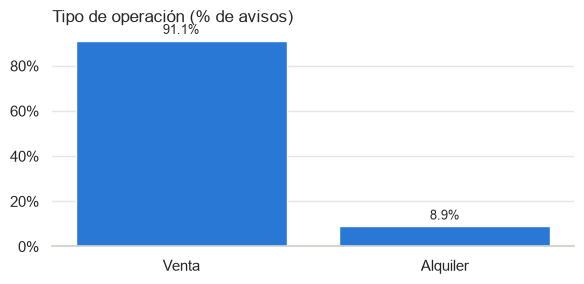

Moneda,ARS,USD,Total
Tipo_Operacion,,,
Alquiler,3402,1541,4943
Venta,17,50622,50639
Total,3419,52163,55582


In [10]:
display(tabla_frecuencias(df['Tipo_Operacion']))

fig, ax = plt.subplots(figsize=(6, 3))
graficar_barras(df['Tipo_Operacion'], 'Tipo de operación (% de avisos)', ax)
plt.tight_layout()
plt.show()

# Moneda de publicación según operación
pd.crosstab(df['Tipo_Operacion'], df['Moneda'], margins=True, margins_name='Total')

In [11]:
# Tipo de alquiler (solo sobre los alquileres)
alquiler = df[df['Tipo_Operacion'] == 'Alquiler']
tabla_frecuencias(alquiler['Tipo_Alquiler'])

,Frecuencia,Porcentaje,% Acumulado
Tipo_Alquiler,,,
Tradicional,239,4.84,4.84
Temporario,215,4.35,9.18
Sin dato,4489,90.82,100.00


In [12]:
# A partir de acá se trabaja con las propiedades en venta
venta = df[df['Tipo_Operacion'] == 'Venta'].copy()
print(f'Propiedades en venta: {len(venta):,}')

Propiedades en venta: 50,639


**Lectura:** el 91,1% de los avisos son ventas y el 8,9% alquileres. Los alquileres están publicados mayormente en pesos (69%), en el 91% no se sabe si son tradicionales o temporarios y sus precios están en otra escala (canon mensual contra valor total del inmueble). Mezclarlos con las ventas distorsionaría cualquier estadístico de precio.

**Decisión:** el EDA se hace sobre las **50.639 propiedades en venta**. Los alquileres se reservan para calcular rentabilidad.

### 3.3 Tipo y subtipo de propiedad

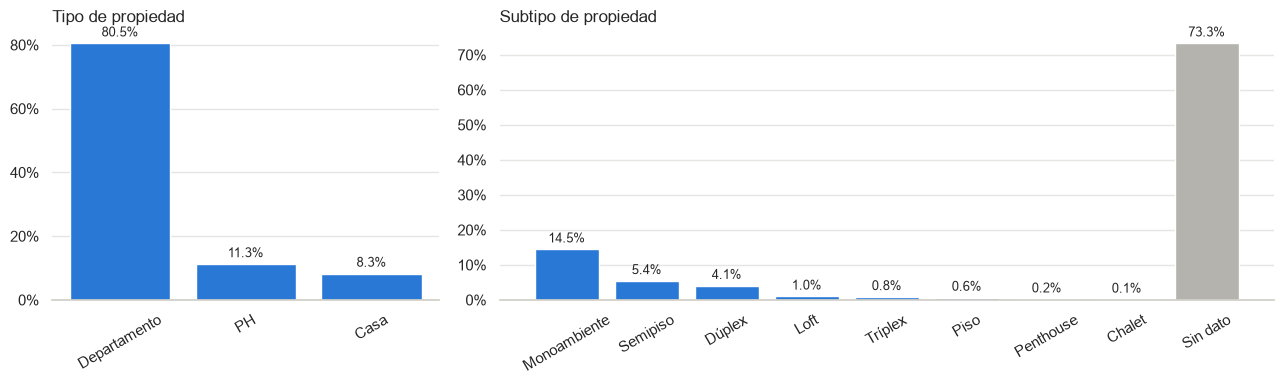

,Frecuencia,Porcentaje,% Acumulado
Tipo_Propiedad,,,
Departamento,40762,80.50,80.50
PH,5697,11.25,91.75
Casa,4180,8.25,100.00


,Frecuencia,Porcentaje,% Acumulado
Subtipo_Propiedad,,,
Monoambiente,7322,14.46,14.46
Semipiso,2744,5.42,19.88
Dúplex,2052,4.05,23.93
Loft,503,0.99,24.92
Tríplex,426,0.84,25.76
Piso,329,0.65,26.41
Penthouse,90,0.18,26.59
Chalet,57,0.11,26.70
Sin dato,37116,73.30,100.00


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [1, 2]})
t_tipo = graficar_barras(venta['Tipo_Propiedad'], 'Tipo de propiedad', axes[0])
t_subtipo = graficar_barras(venta['Subtipo_Propiedad'], 'Subtipo de propiedad', axes[1])
plt.tight_layout()
plt.show()

display(t_tipo)
display(t_subtipo)

**Lectura:** la oferta está dominada por departamentos (80,5%), seguidos por PH (11,3%) y casas (8,3%). Cualquier promedio general de precio va a reflejar sobre todo el mercado de departamentos, así que conviene comparar precios dentro de cada tipo.

`Subtipo_Propiedad` falta en el 73% de los avisos. Entre los que lo informan predomina el monoambiente (54%). Por la cantidad de faltantes, solo sirve como descriptor complementario.

### 3.4 Barrio

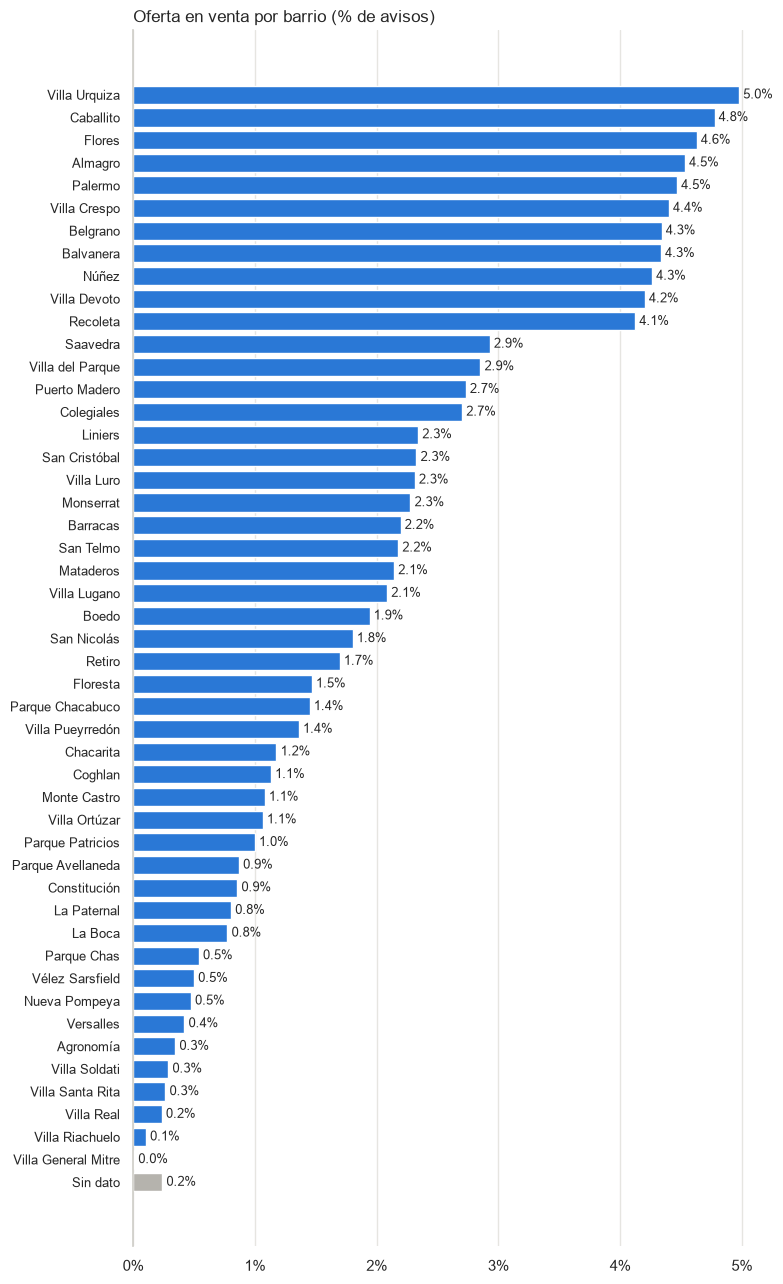

Barrios distintos (normalizado): 48 | barrios distintos (publicado): 52


In [14]:
fig, ax = plt.subplots(figsize=(8, 13))
t_barrio = graficar_barras(venta['Barrio_Normalizado'], 'Oferta en venta por barrio (% de avisos)', ax,
                           horizontal=True, etiquetas=True)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

print('Barrios distintos (normalizado):', venta['Barrio_Normalizado'].nunique(),
      '| barrios distintos (publicado):', venta['Barrio_Publicado'].nunique())

In [15]:
# Concentración de la oferta
t_barrio_sin_na = tabla_frecuencias(venta['Barrio_Normalizado'], incluir_na=False)
print(f"Top 5 barrios: {t_barrio_sin_na['Porcentaje'].head(5).sum():.1f}% de la oferta")
print(f"Top 10 barrios: {t_barrio_sin_na['Porcentaje'].head(10).sum():.1f}% de la oferta")
n_50 = (t_barrio_sin_na['% Acumulado'] < 50).sum() + 1
print(f'Barrios necesarios para acumular el 50% de la oferta: {n_50}')
print('Barrios con menos de 100 avisos:', list(t_barrio_sin_na[t_barrio_sin_na['Frecuencia'] < 100].index))

Top 5 barrios: 23.4% de la oferta
Top 10 barrios: 45.0% de la oferta
Barrios necesarios para acumular el 50% de la oferta: 12
Barrios con menos de 100 avisos: ['Villa Riachuelo', 'Villa General Mitre']


**Lectura:** la muestra cubre los 48 barrios oficiales de CABA y la oferta está repartida. El barrio con más avisos (Villa Urquiza) tiene solo el 5%, los 10 primeros suman el 45% y hacen falta 12 barrios para llegar a la mitad. Hay un grupo de 11 barrios con entre 4% y 5% cada uno (Villa Urquiza, Caballito, Flores, Almagro, Palermo, Villa Crespo, Belgrano, Balvanera, Núñez, Villa Devoto y Recoleta) y después la participación cae.

Villa Riachuelo (53 avisos) y Villa General Mitre (4) tienen muy pocas observaciones: los estadísticos por barrio en esos casos no son confiables.

> ⚠️ Esta distribución describe la **muestra recolectada**, no necesariamente el stock real del mercado: si el scraping se hizo por barrio con un tope de páginas, ese tope achata la parte alta del ranking.

### 3.5 Estado del inmueble, disposición y orientación

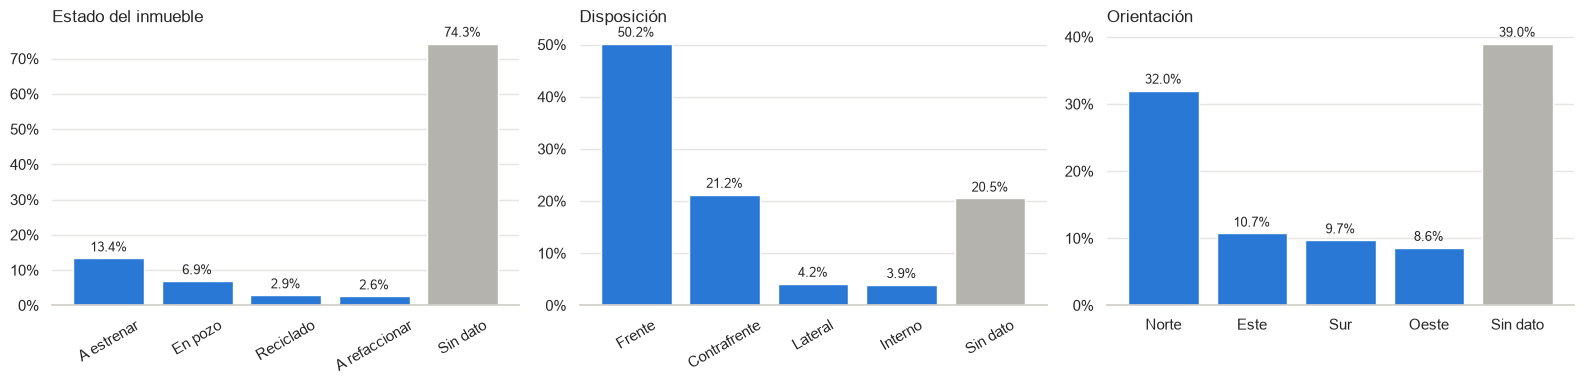

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
graficar_barras(venta['Estado_Inmueble'], 'Estado del inmueble', axes[0])
graficar_barras(venta['Disposicion'], 'Disposición', axes[1])
graficar_barras(venta['Orientacion'], 'Orientación', axes[2])
plt.tight_layout()
plt.show()

Probablemente el 74,3% de los avisos que aparecen como "Sin dato" en `Estado_Inmueble` sean, en su mayoría, **propiedades usadas en estado normal**: ni a estrenar ni para refaccionar, no datos faltantes.

In [17]:
# Las mismas variables considerando solo los avisos que informan el dato
for col in ['Estado_Inmueble', 'Disposicion', 'Orientacion']:
    print(f'--- {col}  (informado en {venta[col].notna().mean():.1%} de los avisos)')
    display(tabla_frecuencias(venta[col], incluir_na=False))

--- Estado_Inmueble  (informado en 25.7% de los avisos)


,Frecuencia,Porcentaje,% Acumulado
Estado_Inmueble,,,
A estrenar,6763,51.93,51.93
En pozo,3487,26.78,78.71
Reciclado,1462,11.23,89.93
A refaccionar,1311,10.07,100.00


--- Disposicion  (informado en 79.5% de los avisos)


,Frecuencia,Porcentaje,% Acumulado
Disposicion,,,
Frente,25416,63.13,63.13
Contrafrente,10749,26.70,89.83
Lateral,2108,5.24,95.06
Interno,1987,4.94,100.00


--- Orientacion  (informado en 61.0% de los avisos)


,Frecuencia,Porcentaje,% Acumulado
Orientacion,,,
Norte,16209,52.48,52.48
Este,5421,17.55,70.03
Sur,4914,15.91,85.94
Oeste,4343,14.06,100.00


**Lectura:**
- **Estado del inmueble** es la variable con más faltantes (74%). Entre los avisos que lo informan, el 52% está a estrenar y el 27% en pozo. El estado lo informan sobre todo los emprendimientos nuevos, así que esta distribución está sesgada hacia lo nuevo. Para el *gap de flipping* hay 1.311 avisos "a refaccionar" y 1.462 "reciclados": alcanzan para comparar, con esa salvedad.
- **Disposición** (informada en el 79,5%): 63% al frente y 27% contrafrente.
- **Orientación** (informada en el 61%): predomina el norte (52%), la más buscada en Buenos Aires. Es posible que se informe más cuando es favorable.

### 3.6 Variables ordinales: ambientes, antigüedad y confort

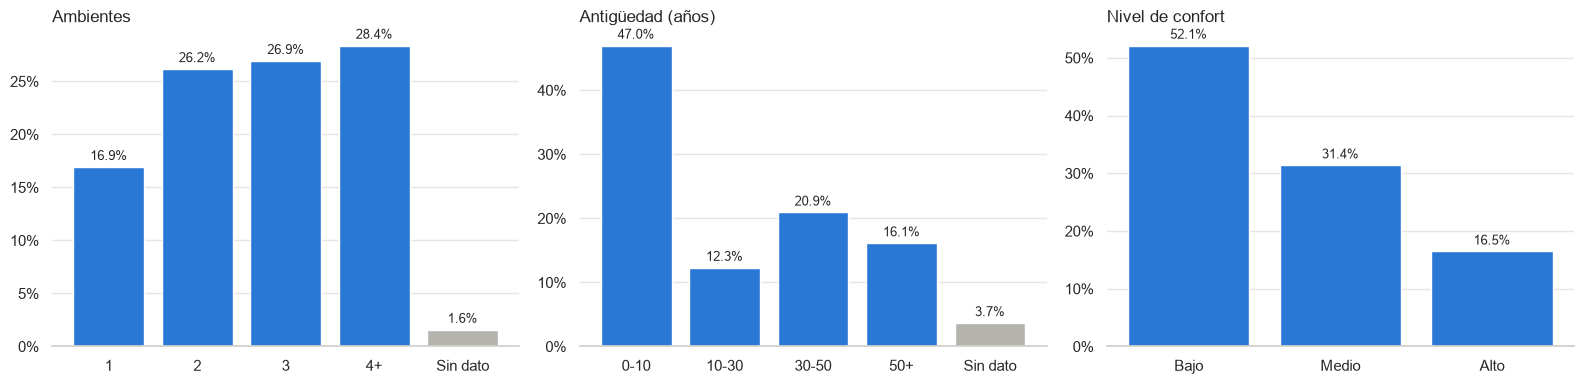

,Frecuencia,Porcentaje,% Acumulado
Ambientes_Agrupado,,,
1,8575,16.93,16.93
2,13252,26.17,43.10
3,13639,26.93,70.04
4+,14370,28.38,98.41
Sin dato,803,1.59,100.00


,Frecuencia,Porcentaje,% Acumulado
Antiguedad_Rango,,,
0-10,23788,46.98,46.98
10-30,6229,12.30,59.28
30-50,10598,20.93,80.20
50+,8168,16.13,96.33
Sin dato,1856,3.67,100.00


,Frecuencia,Porcentaje,% Acumulado
Confort_Rango,,,
Bajo,26403,52.14,52.14
Medio,15897,31.39,83.53
Alto,8339,16.47,100.00


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
graficar_barras(venta['Ambientes_Agrupado'], 'Ambientes', axes[0])
graficar_barras(venta['Antiguedad_Rango'], 'Antigüedad (años)', axes[1])
graficar_barras(venta['Confort_Rango'], 'Nivel de confort', axes[2])
plt.tight_layout()
plt.show()

for col in ORDEN_ORDINALES:
    display(tabla_frecuencias(venta[col]))

### 3.7 Moneda, moneda de expensas y tipo de vendedor

In [19]:
display(tabla_frecuencias(venta['Moneda']))
display(tabla_frecuencias(venta['Moneda_Expensas']))
display(tabla_frecuencias(venta['Tipo_Vendedor']))

# Los pocos avisos con expensas en USD: ¿es una moneda real o un error de etiquetado?
expensas_usd = venta.loc[venta['Moneda_Expensas'] == 'USD']
print(f'Avisos con expensas declaradas en USD: {len(expensas_usd)}')
print(f"  marcados por Flag_Expensas_Anomalas: {expensas_usd['Flag_Expensas_Anomalas'].mean():.0%}")
print(f"  con expensas = 0: {(expensas_usd['Expensas'] == 0).sum()}")
display(expensas_usd.nlargest(5, 'Expensas')[['Expensas_Raw', 'Expensas', 'Precio_USD']])

,Frecuencia,Porcentaje,% Acumulado
Moneda,,,
USD,50622,99.97,99.97
ARS,17,0.03,100.00


,Frecuencia,Porcentaje,% Acumulado
Moneda_Expensas,,,
ARS,47812,94.42,94.42
USD,52,0.10,94.52
Sin dato,2775,5.48,100.00


,Frecuencia,Porcentaje,% Acumulado
Tipo_Vendedor,,,
Inmobiliaria,49929,98.60,98.60
Particular,691,1.36,99.96
Otro,5,0.01,99.97
Sin dato,14,0.03,100.00


Avisos con expensas declaradas en USD: 52
  marcados por Flag_Expensas_Anomalas: 81%
  con expensas = 0: 35


,Expensas_Raw,Expensas,Precio_USD
33771,825.000 USD,"825,000.00","430,000.00"
31187,804.500 USD,"804,500.00","280,000.00"
28875,290.000 USD,"290,000.00","183,900.00"
32522,250.000 USD,"250,000.00","150,000.00"
38453,222.000 USD,"222,000.00","82,000.00"


**Lectura:** las tres variables son prácticamente constantes y se descartan del análisis posterior por no aportar variabilidad.

- **`Moneda`** (99,97% USD): que casi todas las ventas estén en dólares confirma que `Precio_USD` es la variable de precio adecuada.
- **`Tipo_Vendedor`** (98,6% inmobiliaria): con solo un 1,4% de particulares, la muestra no permite contrastar con solidez la hipótesis H6 de la propuesta (que los particulares publicarían por debajo del mercado).
- **`Moneda_Expensas`** (99,89% ARS sobre los avisos que la informan, 5,5% sin dato): las expensas en CABA se cotizan en pesos de forma prácticamente universal.

**Los 52 avisos con expensas en USD no son una categoría real, son un error de etiquetado del scraping.** La evidencia es contundente: el 81% está marcado por `Flag_Expensas_Anomalas`, la mediana de sus expensas es 0, y al mirar el texto original aparecen valores como `"825.000 USD"` o `"804.500 USD"` de expensas mensuales. Leídos como pesos son montos perfectamente normales (825.000 ARS ≈ USD 542 al tipo de cambio del período); leídos como dólares son imposibles. Tras el saneamiento de la sección 4.1 solo sobreviven 10 de esos 52 casos, y 5 de ellos con un valor de 1.

**Implicancia:** esto valida la decisión tomada en la unificación de convertir las expensas asumiendo pesos. El riesgo de esa decisión era tratar como pesos un monto realmente en dólares; el dato muestra que la categoría USD es ruido, no señal.

### 3.8 Variables dicotómicas: amenities y condiciones comerciales

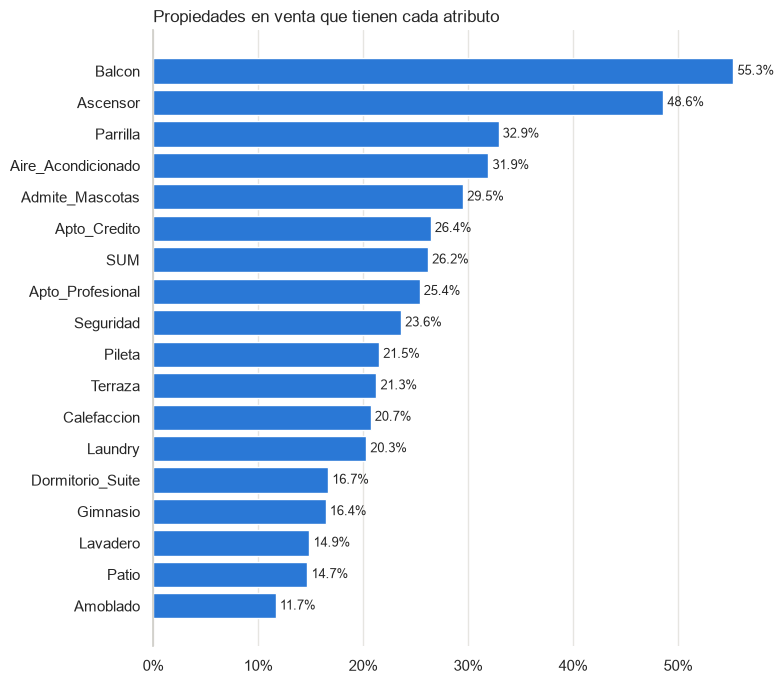

,Grupo,% con el atributo
Balcon,Amenity,55.26
Ascensor,Amenity,48.59
Parrilla,Amenity,32.89
Aire_Acondicionado,Amenity,31.93
Admite_Mascotas,Condición comercial,29.52
Apto_Credito,Condición comercial,26.43
SUM,Amenity,26.17
Apto_Profesional,Condición comercial,25.38
Seguridad,Amenity,23.61
Pileta,Amenity,21.51


In [20]:
presencia = pd.DataFrame({
    'Grupo': ['Condición comercial'] * len(CONDICIONES) + ['Amenity'] * len(AMENITIES),
    '% con el atributo': venta[CONDICIONES + AMENITIES].mean() * 100,
}).sort_values('% con el atributo', ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
barras = ax.barh(presencia.index, presencia['% con el atributo'], color=COLOR)
ax.bar_label(barras, labels=[f'{p:.1f}%' for p in presencia['% con el atributo']], padding=3, fontsize=9)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis='y', visible=False)
ax.set_title('Propiedades en venta que tienen cada atributo', loc='left', fontsize=12)
sns.despine(ax=ax, bottom=True)
plt.tight_layout()
plt.show()

presencia

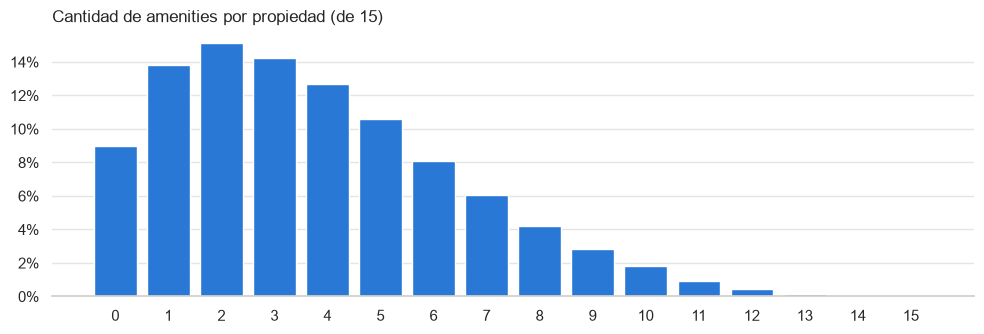

Mediana: 3 amenities


,Frecuencia,Porcentaje,% Acumulado
Cantidad de amenities,,,
0,4539,8.96,8.96
1,7000,13.82,22.79
2,7658,15.12,37.91
3,7206,14.23,52.14
4,6431,12.70,64.84
5,5364,10.59,75.43
6,4102,8.10,83.53
7,3081,6.08,89.62
8,2141,4.23,93.84


In [21]:
# Cantidad de amenities por propiedad (de los 15 considerados)
n_amenities = (venta[AMENITIES].sum(axis=1)
               .astype(pd.CategoricalDtype(range(len(AMENITIES) + 1), ordered=True))
               .rename('Cantidad de amenities'))

fig, ax = plt.subplots(figsize=(10, 3.5))
t_n_amenities = graficar_barras(n_amenities, 'Cantidad de amenities por propiedad (de 15)', ax, etiquetas=False)
plt.tight_layout()
plt.show()

print(f'Mediana: {venta[AMENITIES].sum(axis=1).median():.0f} amenities')
t_n_amenities

**Lectura:**
- Balcón (55%) y ascensor (49%) son los únicos atributos presentes en cerca de la mitad de la oferta.
- Los amenities de edificio son minoritarios: SUM 26%, seguridad 24%, pileta 21,5%, gimnasio 16%. Por eso son candidatos a explicar diferencias de precio (se analiza en la parte multivariada).
- Condiciones comerciales: solo el 26,4% declara ser apto crédito y el 25,4% apto profesional.
- La propiedad típica tiene 3 amenities de 15 (mediana) y menos del 7% tiene 9 o más.

> ⚠️ En estas variables un 0 puede significar "no tiene" o "no lo informó"; no se pueden distinguir. Por eso los porcentajes son un piso.

### 3.9 Calidad del dato: flags de anomalía

In [22]:
flags = (venta[FLAGS].mean() * 100).sort_values(ascending=False).to_frame('% de avisos marcados')
display(flags)

# Motivos individuales (un aviso puede tener varios, separados por " | ")
motivos = (venta['Motivo_Anomalia'].str.split(' | ', regex=False).explode()
           .str.split(':').str[0].str.strip())
motivos.value_counts().to_frame('Avisos')

,% de avisos marcados
Flag_Anomalia_General,62.34
Flag_Expensas_Anomalas,45.15
Flag_Amenities_Anomalos,30.94
Flag_Tipo_Propiedad_Anomalo,2.60
Flag_Ambientes_Anomalo,1.17
Flag_Superficie_Anomala,0.91
Flag_Faltantes_Criticos,0.30
Flag_Operacion_Anomala,0.17
Flag_Coordenadas_Anomalas,0.06
Flag_Precio_Anomalo,0.06


,Avisos
Motivo_Anomalia,
Expensas cero sospechosas,22849
Sin anomalías detectadas,19072
Conflicto ML/texto en amenities,15667
Tipo_Propiedad_ML difiere de Tipo_Propiedad_Inferido,1318
Ambientes cero en propiedad residencial,535
Superficie cubierta mayor a superficie total,420
Superficie total no positiva,171
Faltante crítico,151
Dormitorios mayores a ambientes,141


**Lectura:** el `Flag_Anomalia_General` marca al 62% de las ventas, pero casi todo se explica por dos flags "blandos": expensas en cero (45%) y diferencias entre los amenities de ML y el texto del aviso (31%). Cada una de las anomalías estructurales (tipo de propiedad, ambientes, superficie, precio, coordenadas, operación) afecta a menos del 3%.

**Implicancia para la parte cuantitativa:** no conviene filtrar por el flag general (se perdería el 62% de la muestra). Solo se excluyen los registros con flags estructurales y las expensas en cero se tratan como dato faltante.

### 3.10 Resumen de las variables cualitativas

In [23]:
CUALITATIVAS = ['Tipo_Propiedad', 'Subtipo_Propiedad', 'Barrio_Normalizado', 'Estado_Inmueble',
                'Disposicion', 'Orientacion', 'Ambientes_Agrupado', 'Antiguedad_Rango',
                'Confort_Rango', 'Moneda', 'Moneda_Expensas', 'Tipo_Vendedor']

resumen = []
for col in CUALITATIVAS:
    s = venta[col]
    frec = s.value_counts()
    resumen.append({
        'Variable': col,
        'Categorías': s.nunique(),
        'Moda': frec.index[0],
        '% moda (s/ informados)': frec.iloc[0] / s.notna().sum() * 100,
        '% Sin dato': s.isna().mean() * 100,
    })
pd.DataFrame(resumen).set_index('Variable')

,Categorías,Moda,% moda (s/ informados),% Sin dato
Variable,,,,
Tipo_Propiedad,3,Departamento,80.50,0.00
Subtipo_Propiedad,8,Monoambiente,54.14,73.30
Barrio_Normalizado,48,Villa Urquiza,4.99,0.24
Estado_Inmueble,4,A estrenar,51.93,74.28
Disposicion,4,Frente,63.13,20.50
Orientacion,4,Norte,52.48,39.01
Ambientes_Agrupado,4,4+,28.83,1.59
Antiguedad_Rango,4,0-10,48.76,3.67
Confort_Rango,3,Bajo,52.14,0.00


### Conclusiones del análisis cualitativo

1. **Universo:** propiedades en venta (91% del dataset), publicadas casi en su totalidad en USD y por inmobiliarias.
2. **Perfil de la oferta:** predominan los departamentos (80%), con una distribución pareja entre 2, 3 y 4+ ambientes, y una mitad de la oferta con confort bajo.
3. **Cobertura geográfica:** los 48 barrios están representados; 2 barrios tienen muy pocas observaciones para analizarlos por separado.
4. **Faltantes relevantes:** `Estado_Inmueble` (74%), `Subtipo_Propiedad` (73%) y `Orientacion` (39%). Los análisis que las usen se hacen sobre la submuestra que las informa, aclarando el sesgo.
5. **Variables que se descartan por no tener variabilidad:** `Moneda` (99,97% USD), `Moneda_Expensas` (99,89% ARS), `Tipo_Vendedor` (98,6% inmobiliaria) y `Fuente` (constante). En el caso de `Moneda_Expensas`, además, la categoría minoritaria resultó ser un error de etiquetado del scraping y no una moneda realmente distinta.
6. **Calidad:** las anomalías graves son pocas (<3% cada una); el flag general está inflado por expensas en cero y conflictos de amenities.

## 4. Análisis de variables cuantitativas

Se analizan 25 variables numéricas sobre el mismo universo definido en la sección 3: las **50.639 propiedades en venta**.

### 4.1 Preparación

Las flags de calidad del dataset (`Flag_Precio_Anomalo`, `Flag_Superficie_Anomala`, `Flag_Ambientes_Anomalo`) se diseñaron para filtrar el cálculo de los KPIs, no para describir las variables crudas. Al perfilar las columnas numéricas aparecen valores centinela del scraping que las flags no capturan:

| Variable | Máximo crudo | Percentil 99 |
|---|---|---|
| `Dormitorios` | 1×10¹⁸ | 6 |
| `Ambientes` | 9,99×10¹³ | 8 |
| `Baños` | 9,99×10¹² | 4 |
| `Superficie_Total_m2` | 999.999.999 | 500 |
| `Expensas_USD` | 7,3×10¹³ | 821 |

Con esos valores, `describe()` devuelve una superficie media de 19.977 m² y asimetrías de 224: ningún estadístico es utilizable.

**Decisiones de saneamiento:**

1. **Topes de plausibilidad por variable.** Se define un rango válido para cada variable y los valores fuera de rango se convierten en nulo. Se anula **el valor, no la fila**: un aviso con `Baños` mal cargado puede tener un precio y una superficie perfectamente válidos.
2. **Expensas en cero → nulo.** El 45,1% de las ventas declara expensas igual a 0, lo que en un departamento no es un valor real sino ausencia de dato (ya señalado en la sección 3.9).
3. **`Departamentos_Por_Piso` = 99 es un centinela**, no un dato: aparece 6.661 veces (30% de los avisos que informan el campo) contra una mediana real de 4.
4. **Inconsistencia lógica de superficies:** los avisos donde `Superficie_Total_m2 < Superficie_Cubierta_m2` tienen ambas medidas anuladas, porque no se puede saber cuál de las dos es la equivocada.

In [24]:
# Rangos de plausibilidad. Fuera de rango -> nulo (se anula el valor, no la fila).
LIMITES = {
    'Precio_USD':                (10_000, 20_000_000),  # < 10k USD no es una vivienda en CABA
    'Superficie_Total_m2':       (10, 2_000),
    'Superficie_Cubierta_m2':    (10, 2_000),
    'Superficie_No_Cubierta_m2': (0, 2_000),
    'Superficie_Balcon_m2':      (0, 200),
    'Ambientes':                 (1, 20),
    'Dormitorios':               (0, 15),
    'Baños':                     (0, 10),
    'Cocheras':                  (0, 10),
    'Bauleras':                  (0, 10),
    'Piso':                      (0, 60),   # valores como 301 o 402 son nº de unidad, no piso
    'Cantidad_Pisos_Edificio':   (1, 60),
    'Departamentos_Por_Piso':    (1, 40),   # descarta el centinela 99
    'Expensas_USD':              (1, 5_000),  # el mínimo de 1 descarta las expensas en cero
    'Antiguedad_limpia':         (0, 150),
}

reporte_saneo = []
for col, (minimo, maximo) in LIMITES.items():
    fuera = venta[col].notna() & ~venta[col].between(minimo, maximo)
    venta[col] = venta[col].where(venta[col].between(minimo, maximo))
    reporte_saneo.append({'Variable': col, 'Rango válido': f'[{minimo:,} – {maximo:,}]',
                          'Valores anulados': int(fuera.sum()),
                          '% del universo': fuera.sum() / len(venta) * 100})

# Superficie total menor que la cubierta: inconsistencia lógica, se anulan ambas
inconsistente = venta['Superficie_Total_m2'] < venta['Superficie_Cubierta_m2']
print(f'Avisos con Superficie_Total < Superficie_Cubierta: {inconsistente.sum()} (ambas medidas anuladas)')
venta.loc[inconsistente, ['Superficie_Total_m2', 'Superficie_Cubierta_m2']] = np.nan

pd.DataFrame(reporte_saneo).set_index('Variable')

Avisos con Superficie_Total < Superficie_Cubierta: 210 (ambas medidas anuladas)


,Rango válido,Valores anulados,% del universo
Variable,,,
Precio_USD,"[10,000 – 20,000,000]",32,0.06
Superficie_Total_m2,"[10 – 2,000]",261,0.52
Superficie_Cubierta_m2,"[10 – 2,000]",66,0.13
Superficie_No_Cubierta_m2,"[0 – 2,000]",9,0.02
Superficie_Balcon_m2,[0 – 200],19,0.04
Ambientes,[1 – 20],562,1.11
Dormitorios,[0 – 15],29,0.06
Baños,[0 – 10],27,0.05
Cocheras,[0 – 10],59,0.12


**Lectura:** el saneamiento es quirúrgico. Salvo dos excepciones, ninguna variable pierde más del 1,2% de sus valores: `Precio_USD` pierde 32 valores, `Baños` 27, `Cocheras` 59 y `Ambientes` 562 (1,1%).

Las dos excepciones son informativas en sí mismas:
- **`Departamentos_Por_Piso`** pierde 6.739 valores (13,3%), casi todos el centinela 99. La variable queda con 69,9% de faltantes: sirve como descriptor, no como variable de análisis.
- **`Expensas_USD`** pierde 23.498 valores (46,4%), casi todos ceros. Quedan 24.366 avisos con expensas reales (48,1% del universo), suficientes para describir la variable pero con un sesgo a tener presente: informar las expensas no es aleatorio.

### 4.2 Medidas de resumen y gráficos

Dos funciones que se reutilizan en todos los bloques, en el mismo espíritu que `tabla_frecuencias` de la sección 3:

- `tabla_medidas`: medidas de posición (media, mediana, cuartiles), de dispersión (desvío, CV, IQR, rango) y de forma (asimetría, curtosis).
- `graficar_distribucion`: histograma + boxplot de cada variable, compartiendo el eje horizontal.

In [25]:
def tabla_medidas(datos, columnas):
    """Medidas de posición, dispersión y forma para variables cuantitativas."""
    filas = []
    for col in columnas:
        s = datos[col].dropna()
        q1, q3 = s.quantile([.25, .75])
        filas.append({
            'Variable': col,
            'n': len(s),
            '% Sin dato': datos[col].isna().mean() * 100,
            'Media': s.mean(),
            'Mediana': s.median(),
            'Desvío': s.std(),
            'CV': s.std() / s.mean() if s.mean() else np.nan,
            'Mín': s.min(),
            'Q1': q1,
            'Q3': q3,
            'Máx': s.max(),
            'IQR': q3 - q1,
            'Asimetría': s.skew(),
            'Curtosis': s.kurtosis(),
        })
    return pd.DataFrame(filas).set_index('Variable')


def graficar_distribucion(serie, titulo=None, log=False, bins=60, recorte=0.99):
    """Histograma + boxplot de una variable. `recorte` limita el eje al percentil indicado
    para que la cola larga no aplaste el gráfico (no elimina datos del cálculo)."""
    s = serie.dropna()
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, figsize=(9, 4), sharex=True,
        gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.05})

    sns.boxplot(x=s, ax=ax_box, color=COLOR, fliersize=2, width=0.5)
    ax_box.set(xlabel='', yticks=[])
    sns.despine(ax=ax_box, left=True)

    ax_hist.hist(s, bins=bins, color=COLOR)
    ax_hist.set_xlabel(titulo or serie.name)
    ax_hist.set_ylabel('Avisos')
    sns.despine(ax=ax_hist)

    if log:
        ax_hist.set_xscale('log')
        ax_box.set_xscale('log')
    elif recorte:
        ax_hist.set_xlim(left=min(0, s.min()), right=s.quantile(recorte))

    ax_box.set_title(titulo or serie.name, loc='left', fontsize=12)
    plt.show()


def graficar_bloque(columnas, log=None, recorte=0.99):
    """Dibuja la distribución de cada variable de un bloque."""
    log = log or []
    for col in columnas:
        graficar_distribucion(venta[col], titulo=col, log=col in log, recorte=recorte)

### 4.3 Precio

`Precio_USD` es el precio de publicación y `Precio_m2_USD` el mismo precio dividido por la superficie total.

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Precio_USD,50607,0.06,"219,889.98","146,000.00","299,870.88",1.36,"11,111.00","95,178.50","240,000.00","12,000,000.00","144,821.50",11.88,301.76
Precio_m2_USD,49977,1.31,"2,326.57","2,156.25","1,202.31",0.52,25.14,"1,571.43","2,802.10","23,913.04","1,230.67",2.45,14.48


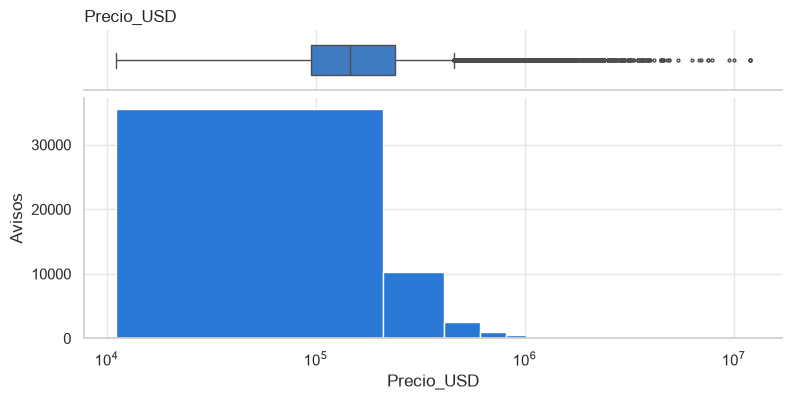

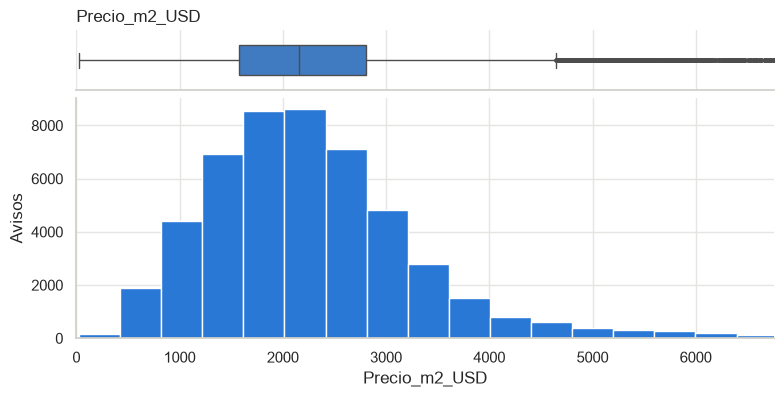

In [26]:
PRECIO = ['Precio_USD', 'Precio_m2_USD']
display(tabla_medidas(venta, PRECIO).round(2))
graficar_bloque(PRECIO, log=['Precio_USD'])

**Lectura:**

- **El precio total está fuertemente sesgado a la derecha.** La media (USD 219.890) es un 51% mayor que la mediana (USD 146.000), con asimetría 11,9 y curtosis 302. La mitad central del mercado se ubica entre USD 95.179 (Q1) y USD 240.000 (Q3). **La media no es un buen resumen de esta variable: corresponde usar la mediana.** Por eso el histograma se muestra en escala logarítmica, donde la distribución se aproxima a una forma acampanada (típico de precios).
- **El precio por m² es mucho más estable.** Su coeficiente de variación es 0,52 contra 1,36 del precio total, y su asimetría baja de 11,9 a 2,5. Es decir: buena parte de la dispersión del precio total se explica simplemente por el tamaño de la propiedad. Esto valida usar `Precio_m2_USD` como variable de comparación entre unidades, tal como se hizo para los KPIs.
- La mediana de USD 2.156/m² es el valor de referencia del mercado; la mitad central va de USD 1.571 a USD 2.802 por m².

### 4.4 Superficie

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Superficie_Total_m2,50071,1.12,100.98,69.00,98.54,0.98,12.00,46.00,115.40,"2,000.00",69.40,4.27,35.90
Superficie_Cubierta_m2,49184,2.87,82.03,59.00,76.32,0.93,10.00,41.00,93.00,"2,000.00",52.00,5.20,59.25
Superficie_No_Cubierta_m2,48983,3.27,19.03,7.00,41.56,2.18,0.00,2.00,17.00,"1,987.00",15.00,11.31,320.20
Superficie_Balcon_m2,17938,64.58,9.68,6.00,12.27,1.27,0.10,4.00,11.00,200.00,7.00,6.06,58.15


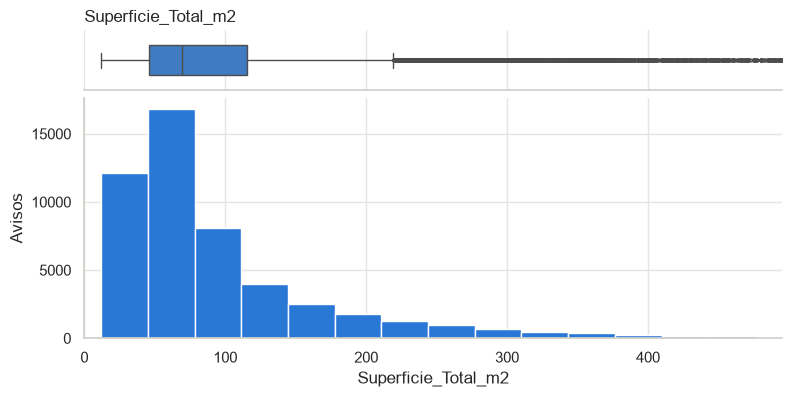

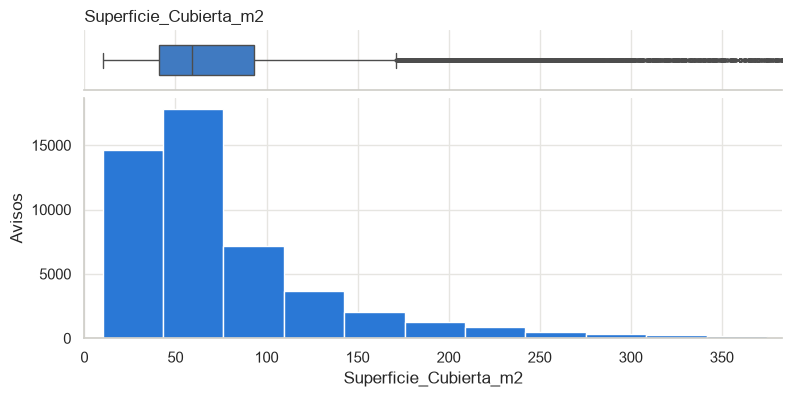

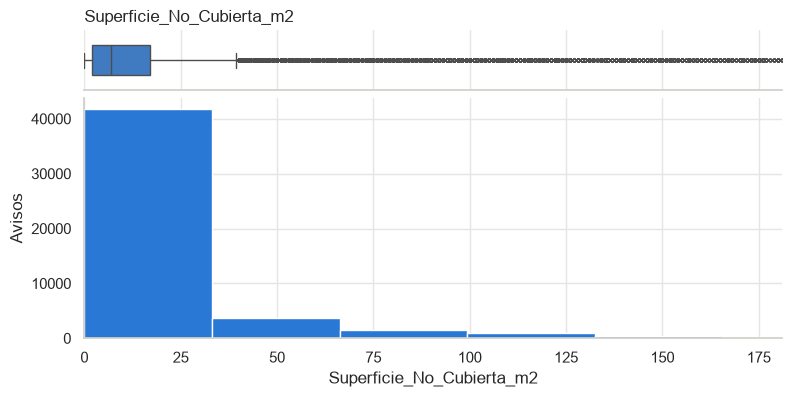

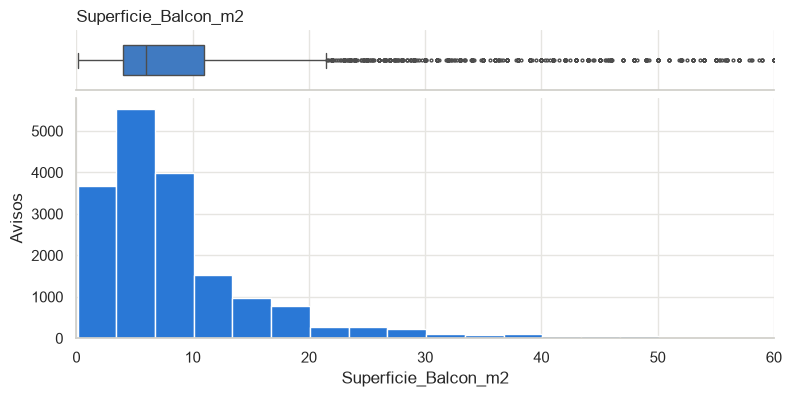

In [27]:
SUPERFICIE = ['Superficie_Total_m2', 'Superficie_Cubierta_m2',
              'Superficie_No_Cubierta_m2', 'Superficie_Balcon_m2']
display(tabla_medidas(venta, SUPERFICIE).round(2))
graficar_bloque(SUPERFICIE)

**Lectura:**

- La propiedad típica tiene **69 m² totales** y 59 m² cubiertos (medianas). Nuevamente la media supera a la mediana (101 y 82 m²): la cola de propiedades grandes estira el promedio.
- La mitad central de la oferta va de 46 a 115 m² totales, un rango consistente con el perfil de 2 y 3 ambientes que domina la muestra.
- **`Superficie_No_Cubierta_m2` tiene mediana 7 m² y asimetría 11,3**: la mayoría de las unidades tiene poco o nada de superficie descubierta, y unas pocas casas con jardín generan toda la cola.
- **`Superficie_Balcon_m2` falta en el 64,6% de los avisos.** Entre los que la informan la mediana es 6 m². Por la cobertura, solo sirve como descriptor complementario.

### 4.5 Composición de la unidad

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Ambientes,49810,1.64,2.88,3.00,1.52,0.53,1.00,2.00,4.00,20.00,2.00,1.69,7.93
Dormitorios,50288,0.69,1.82,2.00,1.32,0.73,0.00,1.00,3.00,15.00,2.00,1.26,5.26
Baños,50338,0.59,1.48,1.00,0.85,0.57,0.00,1.00,2.00,10.00,1.00,2.23,9.14
Cocheras,45703,9.75,0.31,0.00,0.67,2.15,0.00,0.00,0.00,10.00,0.00,3.75,26.98
Bauleras,37393,26.16,0.14,0.00,0.37,2.68,0.00,0.00,0.00,5.00,0.00,2.71,7.95


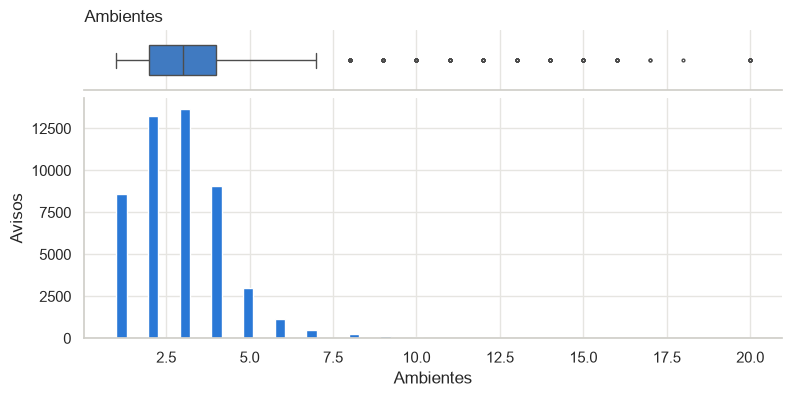

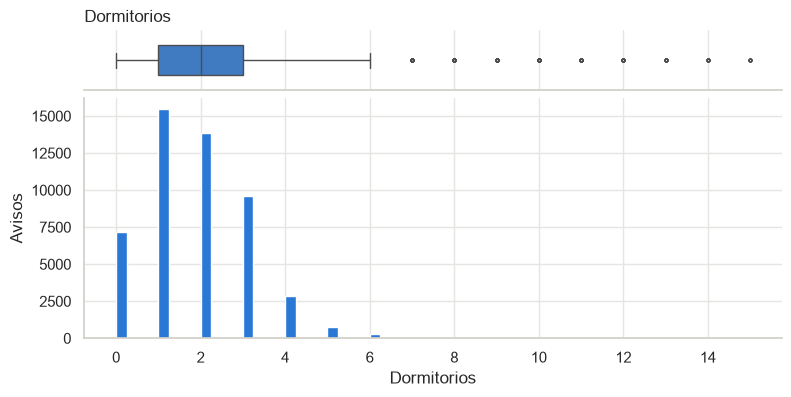

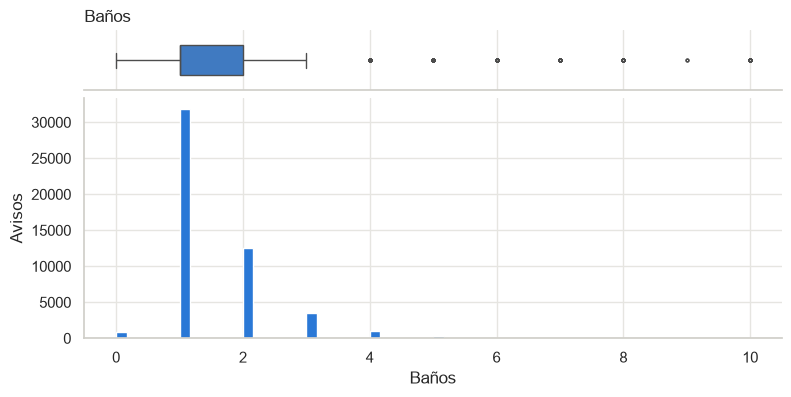

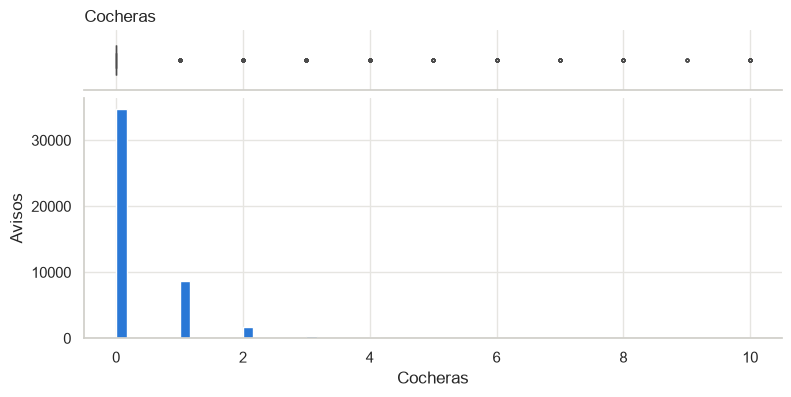

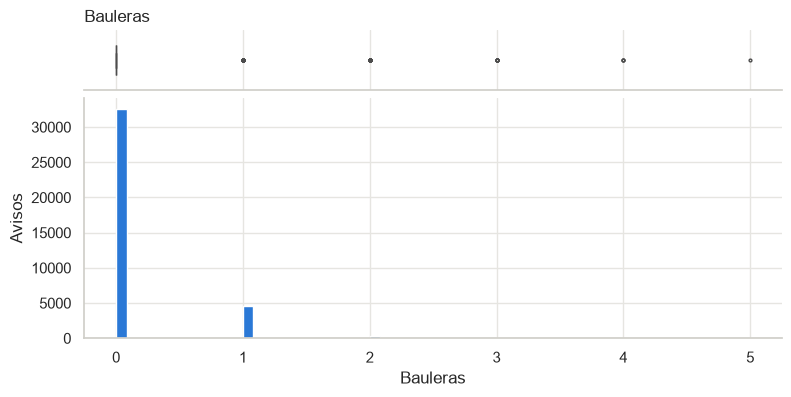

In [28]:
COMPOSICION = ['Ambientes', 'Dormitorios', 'Baños', 'Cocheras', 'Bauleras']
display(tabla_medidas(venta, COMPOSICION).round(2))
graficar_bloque(COMPOSICION, recorte=None)

**Lectura:**

- La unidad típica tiene **3 ambientes, 2 dormitorios y 1 baño** (medianas), con una media de 2,88 ambientes. La distribución es discreta y concentrada: el IQR de ambientes es 2 (de 2 a 4).
- **`Cocheras` y `Bauleras` son en la práctica variables casi dicotómicas**: su mediana, Q1 y Q3 son todos 0 (media 0,31 y 0,14 respectivamente). Lo relevante no es *cuántas* tiene sino *si tiene o no*. Conviene tratarlas como binarias en el análisis multivariado.
- `Bauleras` además falta en el 26,2% de los avisos y `Cocheras` en el 9,8%.

### 4.6 Antigüedad y características del edificio

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Antiguedad_limpia,48783,3.67,23.87,13.00,26.20,1.10,0.00,0.00,46.00,150.00,46.00,0.75,-0.46
Piso,24545,51.53,4.79,4.00,4.15,0.87,1.00,2.00,7.00,55.00,5.00,2.53,12.77
Cantidad_Pisos_Edificio,27238,46.21,6.17,5.00,5.64,0.92,1.00,1.00,9.00,60.00,8.00,2.01,8.50
Departamentos_Por_Piso,15244,69.90,4.22,3.00,3.77,0.89,1.00,2.00,4.00,40.00,2.00,4.13,23.43


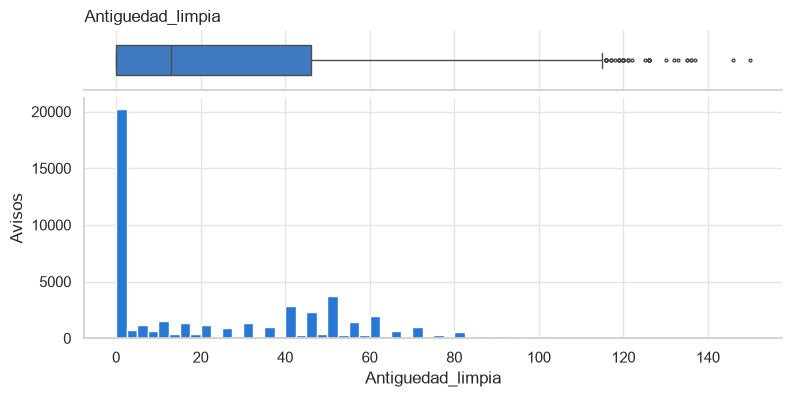

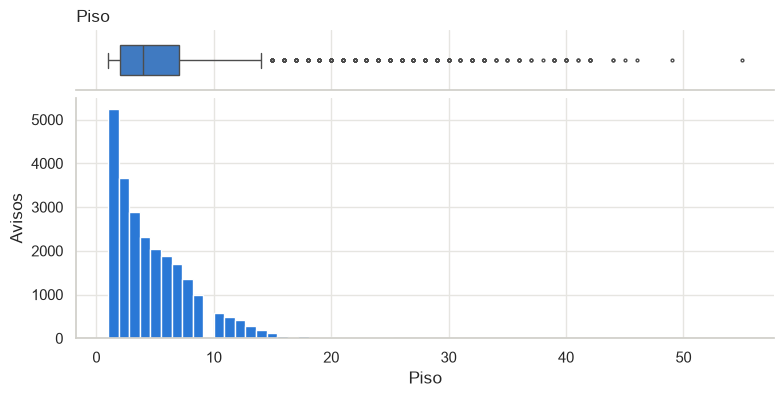

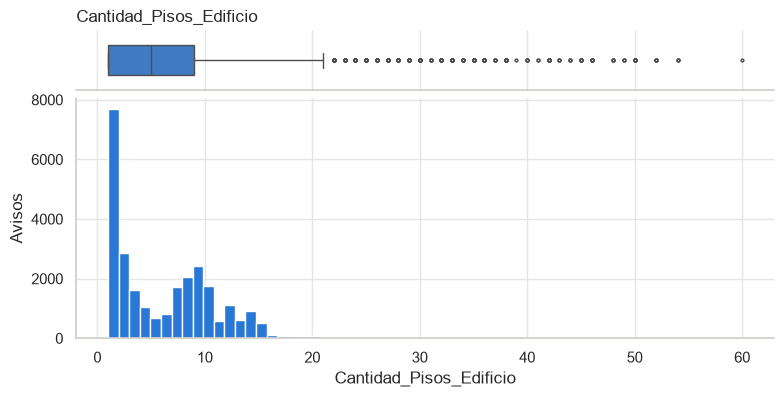

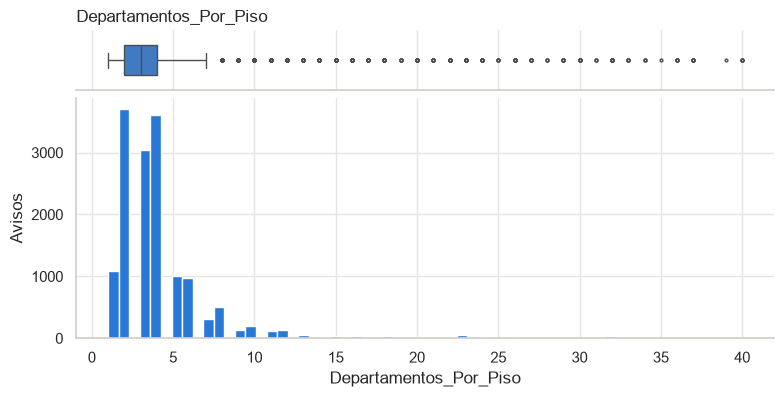

In [29]:
EDIFICIO = ['Antiguedad_limpia', 'Piso', 'Cantidad_Pisos_Edificio', 'Departamentos_Por_Piso']
display(tabla_medidas(venta, EDIFICIO).round(2))
graficar_bloque(EDIFICIO, recorte=None)

**Lectura:**

- **`Antiguedad_limpia` es la variable más simétrica de todo el dataset** (asimetría 0,75, curtosis −0,46), pero esa simetría esconde una forma **bimodal**, no normal:

| Tramo | Avisos |
|---|---|
| 0 a 10 años | 22.830 |
| 10 a 40 años | 8.712 (valle) |
| 40 a 60 años | 11.579 |
| más de 60 años | 5.662 |

  El 37,2% de la oferta declara **exactamente 0 años** (obra nueva o en pozo) y hay un segundo pico entre los 40 y los 60 años, separados por un valle de baja densidad. Esto es coherente con lo visto en la sección 3.5: el mercado mezcla emprendimientos nuevos con stock antiguo. **La media de 23,9 años cae justo en ese valle**, donde casi no hay propiedades reales: es el ejemplo más claro del dataset de por qué la media puede describir mal una distribución. La mediana (13 años) y el uso de `Antiguedad_Rango` capturan mejor el comportamiento.
- **Las tres variables de edificio tienen mucha ausencia de dato**: `Piso` 51,5%, `Cantidad_Pisos_Edificio` 46,2% y `Departamentos_Por_Piso` 69,9%. Ninguna sirve como variable universal, pero sí para analizar la submuestra que las informa.
- Entre los que informan, la unidad típica está en un **4º piso de un edificio de 5 pisos con 3 unidades por planta**: el perfil de edificio de barrio, no de torre.

### 4.7 Expensas

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Expensas_USD,24366,51.88,171.78,117.61,197.47,1.15,1.00,75.56,190.54,"3,636.16",114.98,4.40,30.97


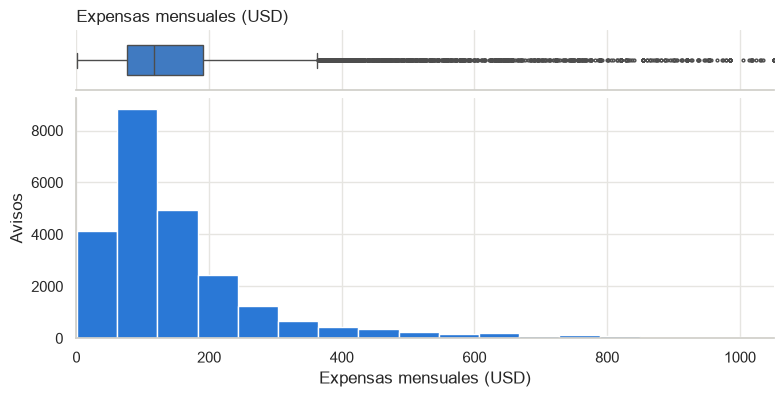

Avisos con expensas y precio válidos: 24,359
Expensas anuales / precio (mediana): 1.13%


In [30]:
display(tabla_medidas(venta, ['Expensas_USD']).round(2))
graficar_distribucion(venta['Expensas_USD'], titulo='Expensas mensuales (USD)')

# Expensas en relación al precio: cuánto pesa el gasto fijo sobre el valor del inmueble
con_expensas = venta[venta['Expensas_USD'].notna() & venta['Precio_USD'].notna()]
print(f'Avisos con expensas y precio válidos: {len(con_expensas):,}')
print(f"Expensas anuales / precio (mediana): {(con_expensas['Expensas_USD'] * 12 / con_expensas['Precio_USD']).median():.2%}")

**Lectura:**

- Entre los 24.366 avisos con expensas reales, la mediana es de **USD 118 por mes** y la mitad central va de USD 76 a USD 191. La media (USD 172) vuelve a estar por encima de la mediana, con asimetría 4,4.
- **Las expensas equivalen al 1,13% anual del valor del inmueble** (mediana). El dato es relevante para el inversor por dos motivos: es el gasto que se descuenta de la renta en la Rentabilidad Neta, y está en el mismo orden de magnitud que el supuesto de mantenimiento del 1% anual usado en ese KPI. En conjunto, ambos conceptos se llevan más de dos puntos de rentabilidad anual, lo que explica la brecha entre la rentabilidad bruta y la neta calculadas en la unificación.
- **Advertencia de sesgo:** el 51,9% del universo quedó sin dato de expensas (mayormente por ceros). Las propiedades que informan expensas son mayoritariamente departamentos en edificios con administración; casas y PH tienden a no tenerlas o a no informarlas. Cualquier estadístico de esta variable describe ese subconjunto, no al mercado completo.

### 4.8 KPIs construidos

`Tasa_Confort_Amenities` (proporción de los 15 amenities presentes) e `Indice_Subvaluacion` (desvío porcentual del precio del aviso respecto de la mediana de su grupo comparable) son variables construidas en la unificación, no observadas.

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Tasa_Confort_Amenities,50639,0.00,0.25,0.20,0.18,0.71,0.00,0.13,0.33,1.00,0.20,0.69,-0.02
Indice_Subvaluacion,47124,6.94,0.02,0.00,0.26,10.80,-0.81,-0.13,0.15,4.73,0.28,1.33,7.91


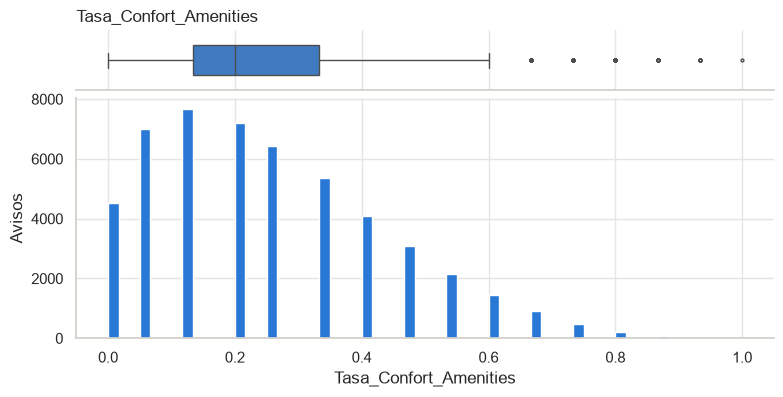

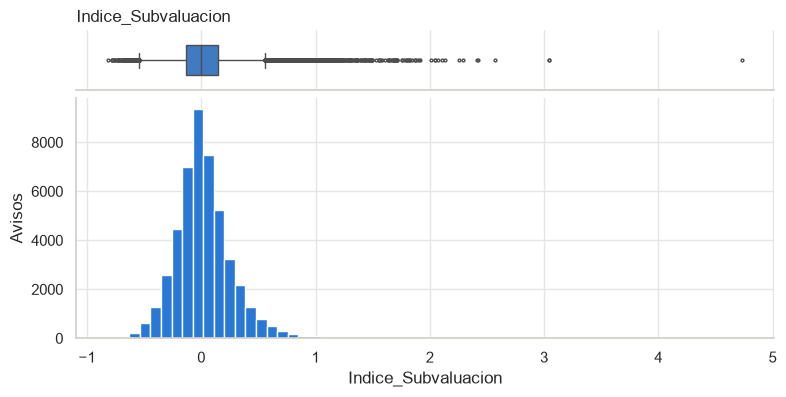

In [31]:
KPIS = ['Tasa_Confort_Amenities', 'Indice_Subvaluacion']
display(tabla_medidas(venta, KPIS).round(3))
graficar_bloque(KPIS, recorte=None)

**Lectura:**

- **`Tasa_Confort_Amenities`**: media 0,25 y mediana 0,20, o sea que la propiedad típica tiene 3 de los 15 amenities relevados. Es la variable de forma más regular del dataset (curtosis −0,02, prácticamente mesocúrtica). El Q3 de 0,33 confirma que el 75% de la oferta tiene 5 amenities o menos.
- **`Indice_Subvaluacion`**: está centrado en 0 por construcción (mediana exactamente 0,00), que es justamente lo que se espera de un índice definido como desvío respecto de la mediana del grupo. El IQR va de −0,13 a +0,15: la mitad central de los avisos está dentro de ±15% del valor de su grupo comparable.
- ⚠️ **El CV de `Indice_Subvaluacion` (10,8) no es interpretable**: el coeficiente de variación pierde sentido cuando la media tiende a cero, porque el denominador colapsa. Para esta variable hay que leer el desvío estándar (0,26) y el IQR, no el CV.
- La cola derecha llega a +4,73 (un aviso a casi 6 veces el valor de su grupo) mientras que la izquierda está acotada en −0,82: un precio no puede estar más de 100% por debajo del predicho. Esa asimetría estructural del índice explica la asimetría 1,33.

### 4.9 Entorno geoespacial

Variables calculadas en la unificación a partir de las coordenadas de cada aviso contra las fuentes de Buenos Aires Data.

,n,% Sin dato,Media,Mediana,Desvío,CV,Mín,Q1,Q3,Máx,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
Distancia_Subte_m,50585,0.11,"1,296.08",701.43,"1,378.52",1.06,1.98,353.57,"1,784.51","17,643.49","1,430.95",1.81,5.15
Distancia_Hospital_m,50585,0.11,"1,275.25","1,180.55",707.33,0.55,9.73,751.15,"1,701.00","13,209.77",949.85,1.80,19.59
Cantidad_Delitos_1000m,50585,0.11,"9,033.57","7,631.00","5,077.58",0.56,0.00,"4,760.00","11,958.00","24,191.00","7,198.00",0.87,-0.16
Cantidad_Colectivos_500m,50585,0.11,35.04,32.00,18.24,0.52,0.00,22.00,45.00,144.00,23.00,1.14,2.13
Distancia_Espacio_Verde_m,50585,0.11,370.39,323.44,303.65,0.82,0.00,194.42,505.45,"12,668.01",311.04,14.96,502.81
Cantidad_Espacios_Verdes_1000m,50585,0.11,6.55,6.00,4.75,0.73,0.00,3.00,8.00,39.00,5.00,1.90,5.36
Superficie_Verde_1000m_m2,50585,0.11,"152,353.83","42,740.68","431,471.29",2.83,0.00,"21,630.76","105,593.38","2,759,731.12","83,962.62",5.15,26.22


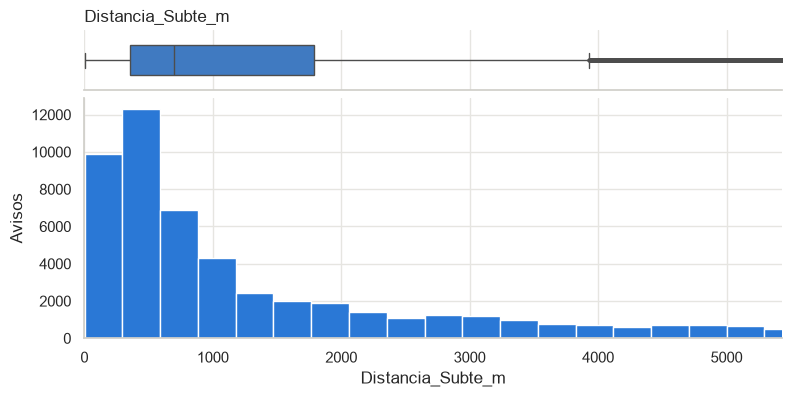

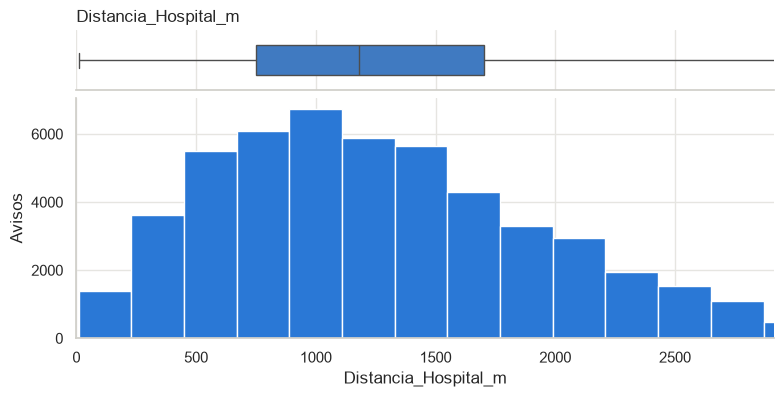

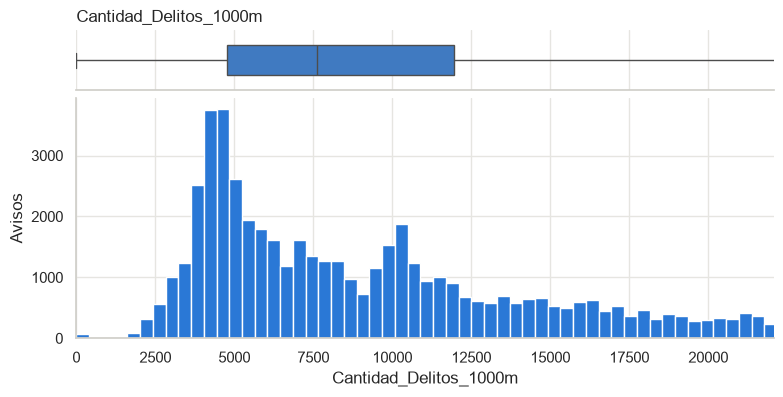

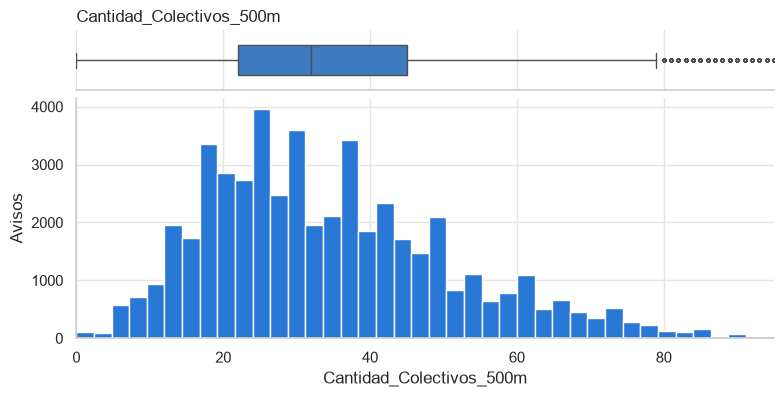

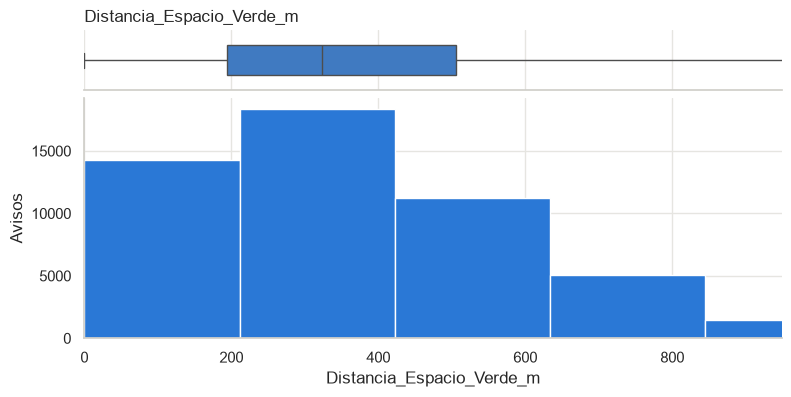

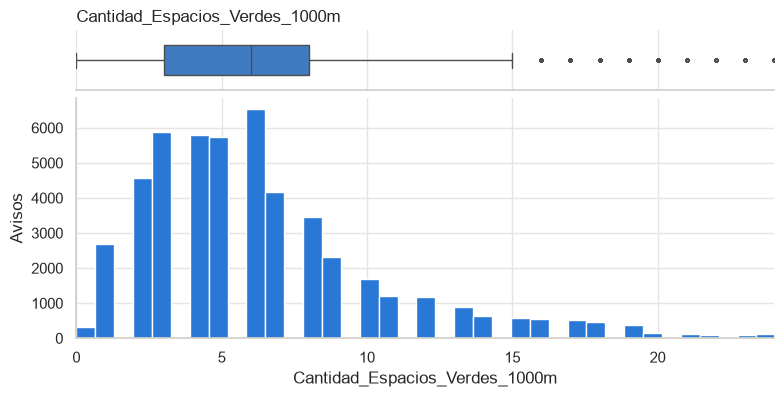

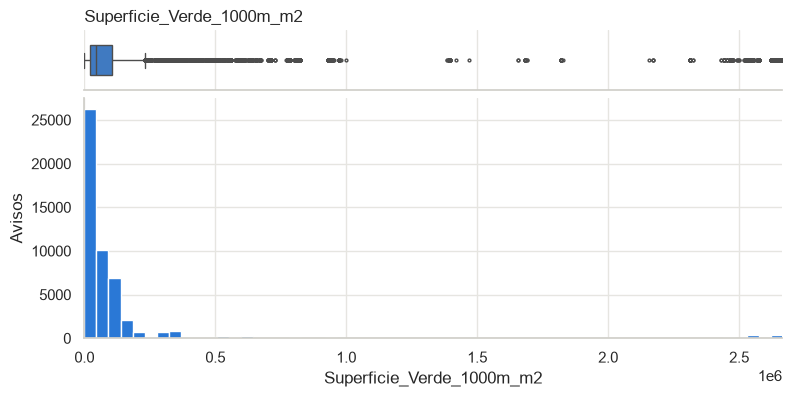

In [32]:
ENTORNO = ['Distancia_Subte_m', 'Distancia_Hospital_m',
           'Cantidad_Delitos_1000m', 'Cantidad_Colectivos_500m',
           'Distancia_Espacio_Verde_m', 'Cantidad_Espacios_Verdes_1000m',
           'Superficie_Verde_1000m_m2']
display(tabla_medidas(venta, ENTORNO).round(2))
graficar_bloque(ENTORNO)

**Lectura:**

**Transporte y servicios**

- **`Distancia_Subte_m` es la variable de entorno más desigual** (CV 1,06, asimetría 1,81): la mediana es de 701 m —unas 7 cuadras— pero el Q3 trepa a 1.785 m y el máximo a 17,6 km. Esto refleja un hecho real de CABA: la red de subte cubre el centro y el norte, y deja prácticamente sin servicio al sur y al oeste. Es una variable con mucho poder para explicar diferencias de precio (hipótesis H4 de la propuesta).
- **`Cantidad_Colectivos_500m` compensa parcialmente esa desigualdad**: mediana de 32 paradas en 500 m y un mínimo de 0, con una distribución mucho más pareja (CV 0,52). Donde no llega el subte, suele llegar el colectivo.
- **`Distancia_Hospital_m`** es la más homogénea en términos de posición (mediana 1.181 m, CV 0,55): la cobertura de salud está razonablemente distribuida en toda la ciudad.
- **`Cantidad_Delitos_1000m` es la variable más simétrica del bloque** (asimetría 0,87, curtosis −0,16) y también la de mayor rango absoluto: de 0 a 24.191 hechos en tres años dentro de un radio de 1 km. La mediana es 7.631. Esa amplitud la vuelve una buena candidata para segmentar zonas (hipótesis H5).

**Espacios verdes: la distancia no discrimina, la superficie sí**

Las tres variables de espacios verdes cuentan historias distintas, y ahí está lo interesante:

- **`Distancia_Espacio_Verde_m` casi no diferencia avisos.** La mediana es de 323 m (unas 3 cuadras) y el 75% de la oferta está a menos de 505 m de alguna plaza. Solo 319 avisos (0,6%) no tienen ningún espacio verde a menos de 1 km. Dicho de otro modo: **"tener una plaza cerca" no es un diferencial en CABA, lo tiene casi todo el mundo.**
- **`Superficie_Verde_1000m_m2` es otra cosa: es la variable más dispersa de todo el bloque de entorno** (CV 2,83 contra 1,06 del subte). La mediana es de 4,3 hectáreas accesibles, pero el Q1 es 2,2 ha y el Q3 10,6 ha: **casi cinco veces de diferencia entre el cuarto peor y el cuarto mejor servido**, y el máximo llega a 276 ha (Puerto Madero, por la Reserva Ecológica).
- `Cantidad_Espacios_Verdes_1000m` (mediana 6) queda en un punto intermedio: informa sobre la cantidad de opciones, pero sin distinguir una plazoleta de un parque.

**Implicancia para el análisis multivariado:** para contrastar la hipótesis H7 (espacios verdes y unidades familiares) conviene usar **`Superficie_Verde_1000m_m2`, no la distancia**. La distancia está saturada —casi todos los avisos puntúan bien— y por lo tanto tiene poca capacidad de explicar diferencias de precio. La superficie verde accesible es la que realmente separa zonas.

> El máximo de 17,6 km al subte y de 12,7 km a un espacio verde corresponden al mismo aviso: en una ciudad de ~20 km de extensión, sugiere coordenadas fuera del ejido de CABA.

### 4.10 Detección de outliers (regla de Tukey)

Se aplica el criterio de 1,5 × IQR sobre todas las variables cuantitativas ya saneadas. La pregunta no es solo *cuántos* outliers hay, sino **si son errores o mercado real**.

In [33]:
CUANTITATIVAS = PRECIO + SUPERFICIE + COMPOSICION + EDIFICIO + ['Expensas_USD'] + KPIS + ENTORNO

filas = []
for col in CUANTITATIVAS:
    s = venta[col].dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    bajos, altos = (s < li).sum(), (s > ls).sum()
    filas.append({'Variable': col, 'Límite inferior': li, 'Límite superior': ls,
                  'Outliers bajos': int(bajos), 'Outliers altos': int(altos),
                  '% outliers': (bajos + altos) / len(s) * 100})

outliers = pd.DataFrame(filas).set_index('Variable').sort_values('% outliers', ascending=False)
outliers.round(2)

,Límite inferior,Límite superior,Outliers bajos,Outliers altos,% outliers
Variable,,,,,
Cocheras,0.00,0.00,0,11019,24.11
Bauleras,0.00,0.00,0,4871,13.03
Superficie_No_Cubierta_m2,-20.50,39.50,0,6378,13.02
Departamentos_Por_Piso,-1.00,7.00,0,1515,9.94
Superficie_Verde_1000m_m2,"-104,313.17","231,537.31",0,4593,9.08
Superficie_Total_m2,-58.09,219.49,0,4487,8.96
Expensas_USD,-96.91,363.01,0,2124,8.72
Superficie_Cubierta_m2,-37.00,171.00,0,4118,8.37
Precio_USD,"-122,053.75","457,232.25",0,4016,7.94


**Lectura:** los resultados se dividen en tres grupos y **ninguno justifica eliminar observaciones**.

1. **Artefacto del método (no son outliers reales).** `Cocheras` (24,1%) y `Bauleras` (13,0%) encabezan el ranking por un motivo puramente aritmético: como Q1 = Q3 = 0, el IQR es 0 y la regla marca como atípico **cualquier** valor distinto de cero. La regla de Tukey no es aplicable a variables cuasi-dicotómicas; para ellas el análisis correcto es el de presencia/ausencia ya hecho en la sección 3.8.

2. **Cola larga legítima del mercado.** `Superficie_No_Cubierta_m2` (13,0%), `Superficie_Total_m2` (9,0%), `Expensas_USD` (8,7%) y `Precio_USD` (7,9%) tienen outliers altos que son propiedades reales: casas con jardín, unidades premium, edificios con amenities caros. Eliminarlos sesgaría el análisis contra el segmento de lujo, que es parte del mercado. La respuesta metodológica correcta es **usar mediana e IQR en lugar de media y desvío**, no borrar datos.

3. **Variables sin problema.** `Cantidad_Delitos_1000m` (0,15%), `Distancia_Hospital_m` (0,35%) y `Antiguedad_limpia` (0,12%) prácticamente no tienen atípicos: su dispersión es amplia pero continua.

El saneamiento de 4.1 ya retiró los valores imposibles; lo que queda es variabilidad genuina del mercado inmobiliario porteño.

### 4.11 Resumen de las variables cuantitativas

In [34]:
resumen_cuanti = tabla_medidas(venta, CUANTITATIVAS)[
    ['n', '% Sin dato', 'Media', 'Mediana', 'Desvío', 'CV', 'Asimetría']
].copy()
resumen_cuanti['Media > Mediana'] = np.where(
    resumen_cuanti['Media'] > resumen_cuanti['Mediana'], 'Sí (cola derecha)', 'No')
resumen_cuanti.round(2)

,n,% Sin dato,Media,Mediana,Desvío,CV,Asimetría,Media > Mediana
Variable,,,,,,,,
Precio_USD,50607,0.06,"219,889.98","146,000.00","299,870.88",1.36,11.88,Sí (cola derecha)
Precio_m2_USD,49977,1.31,"2,326.57","2,156.25","1,202.31",0.52,2.45,Sí (cola derecha)
Superficie_Total_m2,50071,1.12,100.98,69.00,98.54,0.98,4.27,Sí (cola derecha)
Superficie_Cubierta_m2,49184,2.87,82.03,59.00,76.32,0.93,5.20,Sí (cola derecha)
Superficie_No_Cubierta_m2,48983,3.27,19.03,7.00,41.56,2.18,11.31,Sí (cola derecha)
Superficie_Balcon_m2,17938,64.58,9.68,6.00,12.27,1.27,6.06,Sí (cola derecha)
Ambientes,49810,1.64,2.88,3.00,1.52,0.53,1.69,No
Dormitorios,50288,0.69,1.82,2.00,1.32,0.73,1.26,No
Baños,50338,0.59,1.48,1.00,0.85,0.57,2.23,Sí (cola derecha)


### Conclusiones del análisis cuantitativo

1. **Casi todas las variables están sesgadas a la derecha.** En 23 de las 25 la media supera a la mediana (las dos excepciones son `Ambientes` y `Dormitorios`, variables discretas y acotadas). La consecuencia metodológica es directa: **todo el análisis posterior debe apoyarse en la mediana y el IQR**, no en la media y el desvío. Esto ya se había anticipado al construir los KPIs por zona con medianas.

2. **El precio por m² es la variable de comparación correcta.** Normalizar por superficie reduce el coeficiente de variación de 1,36 a 0,52 y la asimetría de 11,9 a 2,5, porque elimina el efecto del tamaño. Mediana de referencia del mercado: **USD 2.156/m²**.

3. **El perfil de la propiedad típica en venta** es: 69 m² totales, 3 ambientes, 2 dormitorios, 1 baño, sin cochera, 13 años de antigüedad, 3 de 15 amenities, USD 146.000 de precio y USD 118 de expensas mensuales.

4. **La antigüedad es bimodal**, no normal: convive un polo de obra nueva (25% con 0 años) con un stock de 40 a 70 años. Analizarla por su media (23,9 años) sería engañoso, porque cae en un valle con poca densidad real. El uso de `Antiguedad_Rango` en la sección 3 ya captura mejor este comportamiento.

5. **Hay tres niveles de disponibilidad de dato.** Variables completas (precio, superficie, ambientes, entorno geoespacial, con menos del 4% de faltantes); variables de cobertura media (expensas 51,9%, cocheras, bauleras); y variables de cobertura baja que solo sirven como descriptores (`Departamentos_Por_Piso` 69,9%, `Superficie_Balcon_m2` 64,6%, `Piso` 51,5%).

6. **Los outliers que sobreviven al saneamiento son mercado, no error.** Salvo el artefacto de Tukey en las variables cuasi-dicotómicas, los atípicos corresponden a propiedades premium reales y se conservan.

7. **El entorno geoespacial aporta variabilidad aprovechable, pero no toda.** La distancia al subte (CV 1,06), la superficie verde accesible (CV 2,83) y la cantidad de delitos son las mejores candidatas para explicar diferencias de precio dentro de un mismo barrio. En cambio **la distancia a un espacio verde está saturada** (el 75% de la oferta tiene una plaza a menos de 505 m) y difícilmente discrimine: para la hipótesis H7 hay que usar superficie, no distancia.